# Installs

In [1]:
!pip install -q numpyro jax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 12.3 MB/s eta 0:00:00


# Imports

In [2]:
"""Bayesian count regression: eleven-way model comparison.

This script compares eleven Bayesian count-regression models on the
**NMES1988** dataset (Deb & Trivedi 1997; distributed in the R AER
package), a canonical count-regression benchmark containing 4,406
observations of physician office visits by elderly U.S. Medicare
beneficiaries in 1987-88.

The response, ``visits``, is an unambiguous non-negative integer count
(number of physician office visits per person, min 0, max 89).
The data is overdispersed with a substantial excess-zero mass,
which makes it a natural showcase for negative-binomial and
zero-inflated likelihoods.

Predictors used (numeric, standardized before modeling):

    - ``chronic``  : number of chronic conditions
    - ``age``      : age in years / 10
    - ``school``   : years of education
    - ``income``   : family income in $10,000

Binary factor predictors (0/1 encoded):

    - ``gender``, ``married``, ``employed``, ``insurance``, ``medicaid``,
      ``afam``, ``adl``   (``adl`` binarized as ``limited`` == 1)

Categorical axes available to the hierarchical models:

    - ``region``  (4 levels: northeast / midwest / west / other)
    - ``health``  (3 levels: poor / average / excellent)

These become the two random-effects grouping variables for
``Hier-NegBin`` (single RE on region) and ``Crossed-NegBin`` (crossed
REs on region + health).

---------------------------------------------------------------------
Models
---------------------------------------------------------------------
    1.  PLN-GLM        - Linear mean + Poisson-Lognormal likelihood
    2.  PLN-BNN        - 2-layer BNN mean + Poisson-Lognormal likelihood
    3.  NegBin-GLM     - Linear mean + Negative Binomial likelihood
    4.  NegBin-BNN     - 2-layer BNN mean + Negative Binomial likelihood
    5.  GP-PLN         - GP (RFF, learnable lengthscale) + Poisson-Lognormal
    6.  GP-NegBin      - GP (RFF, learnable lengthscale) + Negative Binomial
    7.  ZI-NegBin      - Linear mean + Zero-Inflated Negative Binomial
    8.  Hier-NegBin    - Single RE on region + NegBin
    9.  ZI-NegBin-BNN  - 2-layer BNN mean + ZI-NegBin likelihood
    10. GP-ZI-NegBin   - GP mean + ZI-NegBin likelihood
    11. Crossed-NegBin - Crossed REs on region + health

All expose an sklearn-style API (``fit`` / ``predict`` /
``log_predictive`` / ``score``).

Key inference / modeling choices:

*   **Learnable GP lengthscale** via reparameterized Random Fourier Features.
*   **Low-rank MVN variational posterior** for non-PLN models;
    mean-field fallback for PLN variants (per-observation ``eps`` plate).
*   **Two-layer fan-in-scaled Bayesian NN** for BNN means.
*   **Non-centred parameterization** for random-effect hierarchies.
*   **Safe-exp clipping** of ``eta`` before exponentiation to prevent
    numerical overflow under pathological SVI steps.
"""

'Bayesian count regression: eleven-way model comparison.\n\nThis script compares eleven Bayesian count-regression models on the\n**NMES1988** dataset (Deb & Trivedi 1997; distributed in the R AER\npackage), a canonical count-regression benchmark containing 4,406\nobservations of physician office visits by elderly U.S. Medicare\nbeneficiaries in 1987-88.\n\nThe response, ``visits``, is an unambiguous non-negative integer count\n(number of physician office visits per person, min 0, max 89).\nThe data is overdispersed with a substantial excess-zero mass,\nwhich makes it a natural showcase for negative-binomial and\nzero-inflated likelihoods.\n\nPredictors used (numeric, standardized before modeling):\n\n    - ``chronic``  : number of chronic conditions\n    - ``age``      : age in years / 10\n    - ``school``   : years of education\n    - ``income``   : family income in $10,000\n\nBinary factor predictors (0/1 encoded):\n\n    - ``gender``, ``married``, ``employed``, ``insurance``, ``medi

In [3]:
from __future__ import annotations

import gc
import logging
import sys
from dataclasses import dataclass
from typing import Any, ClassVar, Literal, Optional, TypedDict

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
from jax import random
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import (
    AutoLowRankMultivariateNormal,
    AutoNormal,
)
from numpyro.infer.initialization import init_to_sample
from numpyro.optim import Adam
from sklearn.base import BaseEstimator
from sklearn.exceptions import NotFittedError
from sklearn.model_selection import (
    GridSearchCV,
    PredefinedSplit,
    RandomizedSearchCV,
    train_test_split,
)
from sklearn.model_selection._search import BaseSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.utils.validation import check_is_fitted
from scipy.stats import loguniform
import sklearn

# Enable sklearn's metadata-routing API. Our estimators accept
# per-observation kwargs (``groups`` for hierarchical models,
# ``log_offset`` for rate models) that need to reach both ``fit`` AND
# ``score`` during GridSearchCV / RandomizedSearchCV.  Without routing,
# sklearn's default scorer calls ``estimator.score(X_val, y_val)``
# with no extras -- hierarchical models would then raise at predict
# time because they need ``groups``.
sklearn.set_config(enable_metadata_routing=True)

numpyro.set_host_device_count(1)

# Typed Dicts

In [4]:
# =============================================================================
# These TypedDicts document the schema of dict-typed parameters and
# attributes that flow through the pipeline.  They make the structure
# checkable by mypy / pyright and self-documenting for readers, without
# changing any runtime behavior (TypedDicts are erased at runtime).
# =============================================================================
class TuningSpec(TypedDict, total=False):
    """The schema of one entry in a tuning_specs dict.

    Each model name maps to a TuningSpec describing how to search its
    hyperparameter space.  Used by ``MultiModelTuner`` and the run
    strategies.

    Fields:
        strategy: ``"grid"`` for ``GridSearchCV`` (exhaustive enumeration
            of the Cartesian product of ``params``) or ``"random"`` for
            ``RandomizedSearchCV`` (sample ``n_iter`` candidates from
            ``params``).  Defaults to ``"grid"`` if absent.
        params: Mapping from parameter name to either a list of values
            (grid) or a scipy ``rv_frozen`` distribution (random).
        n_iter: Number of candidates to sample.  Required for
            ``"random"``; ignored for ``"grid"``.
        seed: Optional RNG seed for random sampling.  Forwarded to
            ``RandomizedSearchCV(random_state=...)``.
    """
    strategy: Literal["grid", "random"]
    params: dict[str, Any]
    n_iter: int
    seed: int


class SplitMeta(TypedDict, total=False):
    """The schema of ``ThreeWaySplit.meta``.

    Documents the metadata fields populated by ``load_nmes1988_data``
    and read elsewhere in the pipeline.  All fields are optional
    because synthetic test splits need not populate them.

    Fields:
        dataset: Human-readable dataset name (e.g. "NMES1988").
        n_train: Training set size.
        n_val: Validation set size.
        n_test: Test set size.
        n_groups_a: Number of groups along the first hierarchical axis
            (used by hierarchical models).
        n_groups_b: Number of groups along the second hierarchical axis
            (used by crossed-hierarchical models).
    """
    dataset: str
    n_train: int
    n_val: int
    n_test: int
    n_groups_a: int
    n_groups_b: int

# Configs

In [5]:
# =============================================================================
# Typed, frozen views over subsets of the model's flat constructor kwargs.
# Each mixin reads its hyperparameters from a typed config (via a property
# on ``BayesianCountRegressor``) instead of reaching into ``self`` for
# loose attribute names.  Benefits:
#
#   - Self-documenting: ``self.bnn_config.hidden`` makes the dependency
#     explicit (reader knows hidden is a BNN concern, not a base-class one).
#   - IDE / type-checker friendly: dataclass fields are typed; Pylance,
#     mypy, etc. can verify use sites.
#   - Decouples mixin code from the base-class kwarg layout: future
#     refactors of the flat kwarg list don't require edits to mixin code.
#
# Implementation: the configs are ALWAYS-FRESH PROPERTIES on the base
# class, computed on access from the underlying flat attributes.  No
# caching, no staleness risk, no synchronization burden after
# ``set_params(...)`` from sklearn.
#
# IMPORTANT: the configs are *derived views*, not the canonical state.
# Tuning specs still reference flat kwarg names (``"lr"``,
# ``"tau_prior_scale"``), and ``get_params()`` / ``set_params()`` /
# ``clone()`` continue to operate on the flat attributes.  This keeps
# full sklearn API compatibility.
# =============================================================================
@dataclass(frozen=True)
class OptimizationConfig:
    """SVI optimization knobs read by the base class fit loop."""
    n_steps: int
    lr: float
    seed: int
    eta_clip: float
    guide_rank: int
    n_samples: int


@dataclass(frozen=True)
class EarlyStoppingConfig:
    """Validation-driven early stopping controls.

    All three fields cooperate: when ``enabled=True``, the SVI loop
    evaluates val ELPD every ``check_every`` steps and bails after
    ``patience`` consecutive non-improvements.
    """
    enabled: bool
    check_every: int
    patience: int


@dataclass(frozen=True)
class BNNConfig:
    """Bayesian NN architecture knob (read by ``_BNNMean``)."""
    hidden: int


@dataclass(frozen=True)
class GPConfig:
    """Random-Fourier-Feature GP knobs (read by ``_RFFMean``).

    ``lengthscale`` is the *initialization* of the log-normal prior on
    the RBF lengthscale, not a fixed value -- SVI fits the lengthscale.
    """
    n_rff: int
    lengthscale: float


@dataclass(frozen=True)
class HierarchicalConfig:
    """Single-axis random-intercept knobs (read by ``_HierarchicalLinearMean``).

    ``n_groups=0`` means "infer from training data at fit time".
    ``tau_prior_scale`` parameterizes ``HalfNormal(scale)`` on the
    random-intercept SD; smaller -> more pooling; larger -> less.
    """
    n_groups: int
    tau_prior_scale: float


@dataclass(frozen=True)
class CrossedHierarchicalConfig:
    """Crossed random-intercept knobs (read by ``_CrossedHierarchicalLinearMean``).

    Two independent random-effect axes a and b, each with its own group
    count and prior scale.  See ``HierarchicalConfig`` for semantics.
    """
    n_groups_a: int
    n_groups_b: int
    tau_a_prior_scale: float
    tau_b_prior_scale: float


@dataclass(frozen=True)
class PLNConfig:
    """Poisson-lognormal Monte Carlo knob (read by ``_PoissonLognormalLik``).

    ``eps_samples`` is K, the number of latent eps draws per posterior
    sample when computing held-out log-predictive density.  Higher K
    reduces estimator variance; the estimator is consistent (converges
    to the true value) and downward-biased at finite K via Jensen.
    """
    eps_samples: int

# Utilities

In [6]:
# =============================================================================
#: Logger for progress messages.  Receives all banner / per-model
#: log lines emitted by the strategies and tuners.  Quiet by default
#: until ``configure_logging()`` is called.
# =============================================================================
logger = logging.getLogger(__name__)


def configure_logging(level: int = logging.INFO) -> None:
    """Wire compare_models's logger to stdout at the given level.

    The handler uses a ``%(message)s``-only format so log lines look
    indistinguishable from old plain ``print(...)`` output -- no
    timestamp, no level prefix.  The intent is "make output configurable
    without changing what users see by default."

    Output stream is ``sys.stdout`` (not the ``logging`` default of
    ``sys.stderr``).

    Args:
        level: Standard ``logging`` level constant.  ``logging.INFO``
            (default) shows progress; ``logging.WARNING`` suppresses it;
            ``logging.DEBUG`` would show DEBUG-level logs if any are added.
    """
    handler = logging.StreamHandler(sys.stdout)
    handler.setFormatter(logging.Formatter("%(message)s"))
    # Replace any existing handlers so re-calling is idempotent.
    logger.handlers = [handler]
    logger.setLevel(level)
    # Don't propagate to root logger -- avoids double-printing if the
    # consumer has also configured logging for their own modules.
    logger.propagate = False


# Auto-configure at import. Override with ``configure_logging(...)``
configure_logging()


def _to_jax_params(params: dict[str, Any]) -> dict[str, Any]:
    """Coerce numpy-like values to jax arrays for model/guide consumption.

    Handles ``np.ndarray``, lists, tuples, and 0-d numpy scalars.  Plain
    Python scalars, jax arrays, and ``None`` pass through unchanged.
    """
    def _convert(v: Any) -> Any:
        if isinstance(v, (np.ndarray, list, tuple)):
            return jnp.asarray(v)
        if isinstance(v, np.generic):       # np.int64, np.float32, ...
            return jnp.asarray(v)
        return v
    return {k: _convert(v) for k, v in params.items()}

# Data

In [7]:
NMES_CSV_URL: str = (
    "https://vincentarelbundock.github.io/Rdatasets/csv/AER/NMES1988.csv"
)

# Numeric predictors used in the standardized feature matrix.
NUMERIC_FEATURE_COLS: list[str] = ["chronic", "age", "school", "income"]

# Binary factor predictors.  For each column we record the level that
# encodes "1" (the other level encodes "0").
BINARY_FEATURE_COLS: list[tuple[str, str]] = [
    ("gender", "female"),       # female = 1, male = 0
    ("married", "yes"),
    ("employed", "yes"),
    ("insurance", "yes"),
    ("medicaid", "yes"),
    ("afam", "yes"),
    ("adl", "limited"),         # limited = 1, normal = 0
]

# Categorical axes used as random-effects grouping variables.
GROUP_A_COL: str = "region"     # 4 levels
GROUP_B_COL: str = "health"     # 3 levels


@dataclass
class ThreeWaySplit:
    """Container bundling train / validation / test arrays for count regression.

    Generic across datasets: the feature matrix holds both numeric and
    binary-encoded predictors, and two independent categorical axes are
    exposed for random-effects modeling.  The response is guaranteed
    to be a non-negative integer (``dtype`` is a numpy integer type).

    The validation arrays are optional: if the loader was called with
    ``val_size=0``, every ``*_val`` field is ``None``.  When present,
    the validation set is intended for monitoring SVI convergence,
    early stopping, and hyperparameter selection without touching the
    held-out test set.

    Attributes:
        X_train / X_val / X_test: Feature matrices, shape ``(n, n_features)``.
            Numeric columns are standardized on the *training* set only;
            binary columns are in {0.0, 1.0}.  ``X_val`` is ``None`` if
            no validation split was requested.
        y_train / y_val / y_test: Non-negative integer counts, shape ``(n,)``.
            ``y_val`` is ``None`` if no validation split was requested.
        groups_a_train / _val / _test: 0-indexed codes for the first
            random-effects categorical axis, shape ``(n,)``.
            ``groups_a_val`` is ``None`` if no validation split.
        groups_b_train / _val / _test: Same for the second axis.
        log_offset_train / _val / _test: Optional log-exposure vectors.
            ``None`` when the dataset has no natural exposure (as in
            NMES1988 where every individual is observed for one year).
            When set, the models fit ``log E[y|x] = eta + log_offset``.
        feature_names: Column labels for the ``X_*`` matrices.
        meta: Dataset summary statistics and provenance, including
            per-split counts and cell-occupancy tables.
    """
    X_train: np.ndarray
    X_val: Optional[np.ndarray]
    X_test: np.ndarray
    y_train: np.ndarray
    y_val: Optional[np.ndarray]
    y_test: np.ndarray
    groups_a_train: np.ndarray
    groups_a_val: Optional[np.ndarray]
    groups_a_test: np.ndarray
    groups_b_train: np.ndarray
    groups_b_val: Optional[np.ndarray]
    groups_b_test: np.ndarray
    log_offset_train: Optional[np.ndarray]
    log_offset_val: Optional[np.ndarray]
    log_offset_test: Optional[np.ndarray]
    feature_names: list[str]
    meta: SplitMeta


def _encode_binary(
    col: np.ndarray,
    true_value: str,
) -> np.ndarray:
    """Encode a string factor column as 0.0 / 1.0 by equality to ``true_value``."""
    return (col == true_value).astype(np.float32)


def load_nmes1988_data(
    test_size: float = 0.2,
    val_size: float = 0.1,
    seed: int = 0,
    url: str = NMES_CSV_URL,
    stratify_by: Optional[str] = 'group_ab',
) -> ThreeWaySplit:
    """Load NMES1988 via the Rdatasets CSV mirror and build a ``ThreeWaySplit``.

    This downloads the canonical AER-package version of the 1988 U.S.
    National Medical Expenditure Survey subset used in Deb & Trivedi
    (1997) and Cameron & Trivedi (2013).  The response ``visits`` is an
    unambiguous non-negative integer (number of physician office visits
    in 1987-88); no rounding or coercion is performed.

    The split is three-way (train / validation / test) with optional
    stratification on the crossed categorical grouping variables.
    Stratification is strongly recommended for hierarchical models --
    without it, some region x health cells could end up with very few
    (or zero) training observations, making their random intercepts
    poorly identified.  With a crossed grid of 4 x 3 = 12 cells and
    ~4,400 observations, stratification guarantees every cell is
    represented in train, val, and test in proportion to its population
    frequency.

    Args:
        test_size: Fraction of observations reserved for final evaluation
            (default 0.20).
        val_size: Fraction of observations reserved for validation
            (default 0.10 of the original dataset).  Set to 0 to skip
            the validation split and return None for val fields.
        seed: Random seed controlling the train/val/test split.
        url: HTTP URL of the NMES1988 CSV file.
        stratify_by: One of ``"group_a"``, ``"group_b"``, ``"group_ab"``,
            or ``None``.  ``"group_ab"`` (default) stratifies on the
            crossed region x health cells.  ``None`` disables stratification.

    Returns:
        A ``ThreeWaySplit`` with train / validation / test arrays,
        integer counts, and two categorical grouping arrays.

    Raises:
        ValueError: If the loaded response is not a non-negative integer,
            or if ``stratify_by`` is not a recognized value.
    """
    df = _fetch_nmes1988_dataframe(url)

    # --- Response ---------------------------------------------------------
    y_raw = df["visits"].values
    # Hard check: NMES1988's `visits` must be integer-typed and
    # non-negative.
    y = np.asarray(y_raw)
    if not np.issubdtype(y.dtype, np.integer):
        # Try safe coercion and verify.
        y_int = y.astype(np.int64)
        if not np.allclose(y_int, y):
            raise ValueError(
                "Response `visits` is not integer-valued; refusing to "
                "coerce silently.  Inspect the data source."
            )
        y = y_int
    if (y < 0).any():
        raise ValueError("Response `visits` contains negative values.")

    # --- Numeric predictors ----------------------------------------------
    X_num = df[NUMERIC_FEATURE_COLS].values.astype(float)
    num_names = list(NUMERIC_FEATURE_COLS)

    # --- Binary factor predictors ----------------------------------------
    bin_cols = [
        _encode_binary(df[c].values, true_val)
        for c, true_val in BINARY_FEATURE_COLS
    ]
    X_bin = np.column_stack(bin_cols) if bin_cols else np.empty((len(df), 0))
    bin_names = [f"{c}__{v}" for c, v in BINARY_FEATURE_COLS]

    # --- Group indices (0-indexed) ---------------------------------------
    groups_a, levels_a = pd.factorize(df[GROUP_A_COL], sort=True)
    groups_b, levels_b = pd.factorize(df[GROUP_B_COL], sort=True)
    groups_a = groups_a.astype(np.int64)
    groups_b = groups_b.astype(np.int64)

    # --- Build stratification vector --------------------------------------
    # For hierarchical models, we want the test/val splits to preserve
    # the joint distribution of (region, health) so every cell appears
    # in every split in proportion to its training share.  The crossed
    # cells are encoded as a single integer per row: n_groups_b * a + b.
    if stratify_by is None:
        strat = None
    elif stratify_by == "group_a":
        strat = groups_a
    elif stratify_by == "group_b":
        strat = groups_b
    elif stratify_by == "group_ab":
        strat = groups_a * len(levels_b) + groups_b
    else:
        raise ValueError(
            f"Unknown stratify_by={stratify_by!r}; "
            f"expected 'group_a', 'group_b', 'group_ab', or None."
        )

    # --- Three-way split: train+val / test, then train / val -------------
    # sklearn doesn't do 3-way splits in one call, so we nest two.
    # We first peel off the test set, then split the remainder into
    # train and validation.
    idx_all = np.arange(len(y))
    if val_size > 0:
        rel_val = val_size / (1.0 - test_size)   # val share of the non-test
    else:
        rel_val = 0.0

    idx_trainval, idx_test = train_test_split(
        idx_all,
        test_size=test_size,
        random_state=seed,
        stratify=strat,
    )
    if rel_val > 0:
        strat_trainval = strat[idx_trainval] if strat is not None else None
        idx_train, idx_val = train_test_split(
            idx_trainval,
            test_size=rel_val,
            random_state=seed + 1,
            stratify=strat_trainval,
        )
    else:
        idx_train = idx_trainval
        idx_val = np.empty(0, dtype=np.int64)

    def _take(
        arr: np.ndarray,
        idx: np.ndarray,
    ) -> np.ndarray:
        return arr[idx] if len(idx) > 0 else np.empty(
            (0,) + arr.shape[1:],
            dtype=arr.dtype,
        )

    # --- Scale numeric-only on train; apply to val+test ------------------
    scaler = StandardScaler().fit(_take(X_num, idx_train))
    X_num_tr = scaler.transform(_take(X_num, idx_train)).astype(np.float32)
    X_num_va = (scaler.transform(_take(X_num, idx_val)).astype(np.float32)
                if len(idx_val) > 0 else np.empty(
                    (0, X_num.shape[1]),
                    dtype=np.float32,
                ))
    X_num_te = scaler.transform(_take(X_num, idx_test)).astype(np.float32)

    X_bin_tr = _take(X_bin, idx_train).astype(np.float32)
    X_bin_va = _take(X_bin, idx_val).astype(np.float32)
    X_bin_te = _take(X_bin, idx_test).astype(np.float32)

    X_train = np.concatenate([X_num_tr, X_bin_tr], axis=1)
    X_val = np.concatenate([X_num_va, X_bin_va], axis=1) if len(idx_val) else None
    X_test = np.concatenate([X_num_te, X_bin_te], axis=1)
    feature_names = num_names + bin_names

    # --- Build per-split integer arrays ----------------------------------
    y_tr = y[idx_train].astype(np.int64)
    y_va = y[idx_val].astype(np.int64) if len(idx_val) else None
    y_te = y[idx_test].astype(np.int64)
    ga_tr = groups_a[idx_train]
    ga_va = groups_a[idx_val] if len(idx_val) else None
    ga_te = groups_a[idx_test]
    gb_tr = groups_b[idx_train]
    gb_va = groups_b[idx_val] if len(idx_val) else None
    gb_te = groups_b[idx_test]

    # --- Compute per-cell counts for the meta report ---------------------
    def _cell_counts(
        a: np.ndarray,
        b: np.ndarray,
    ) -> dict[tuple[int, int], int]:
        if len(a) == 0:
            return {}
        arr = np.column_stack([a, b])
        uniq, cnt = np.unique(arr, axis=0, return_counts=True)
        return {(int(u[0]), int(u[1])): int(c) for u, c in zip(uniq, cnt)}

    meta = {
        "dataset": "NMES1988",
        "n": int(len(y)),
        "n_train": int(len(idx_train)),
        "n_val": int(len(idx_val)),
        "n_test": int(len(idx_test)),
        "n_features": int(X_train.shape[1]),
        "n_numeric_features": int(X_num.shape[1]),
        "n_binary_features": int(X_bin.shape[1]),
        "n_groups_a": int(len(levels_a)),
        "n_groups_b": int(len(levels_b)),
        "group_a_name": GROUP_A_COL,
        "group_b_name": GROUP_B_COL,
        "group_a_levels": list(map(str, levels_a)),
        "group_b_levels": list(map(str, levels_b)),
        "stratify_by": stratify_by,
        "mean_y": float(y.mean()),
        "var_y": float(y.var()),
        "pct_zero": float((y == 0).mean() * 100),
        "max_y": int(y.max()),
        "dispersion_ratio": float(y.var() / max(y.mean(), 1e-8)),
        "cells_train": _cell_counts(ga_tr, gb_tr),
        "cells_val": _cell_counts(ga_va, gb_va) if ga_va is not None else {},
        "cells_test": _cell_counts(ga_te, gb_te),
    }
    return ThreeWaySplit(
        X_train=X_train,
        X_val=X_val,
        X_test=X_test,
        y_train=y_tr,
        y_val=y_va,
        y_test=y_te,
        groups_a_train=ga_tr,
        groups_a_val=ga_va,
        groups_a_test=ga_te,
        groups_b_train=gb_tr,
        groups_b_val=gb_va,
        groups_b_test=gb_te,
        log_offset_train=None,
        log_offset_val=None,
        log_offset_test=None,
        feature_names=feature_names,
        meta=meta,
    )


def _fetch_nmes1988_dataframe(url: str) -> pd.DataFrame:
    """Download NMES1988 from ``url`` and return a pandas DataFrame.

    Split out so that environments with restricted network access can
    monkeypatch this single function to load from disk instead.  The
    Rdatasets CSV has an unnamed index column which we drop.
    """
    df = pd.read_csv(url)
    # Rdatasets CSVs prepend an unnamed index column.
    if df.columns[0].startswith("Unnamed") or df.columns[0] == "rownames":
        df = df.drop(df.columns[0], axis=1)
    return df

# Mixins

## Means

In [8]:
# =============================================================================
# Each mean mixin contributes three methods:
#   _sample_eta    : sample latent parameters inside the NumPyro
#                             model and return the (n_obs,)-vector log-rate.
#   _eta_from_posterior     : given posterior samples, reconstruct the
#                             (n_samples, n_obs) log-rate at test time.
#   _pre_fit_setup          : optional one-time setup run before SVI starts.
# =============================================================================
class _LinearMean:
    """Generalized linear log-rate: eta = alpha + X @ beta."""

    #: This mixin needs no constructor params beyond the base class.
    _required_init_params: ClassVar[tuple[str, ...]] = ()

    def _sample_eta(
        self,
        X: jnp.ndarray,
        n_feat: int,
        **fit_params: Any,
    ) -> jnp.ndarray:
        """Sample intercept and slopes, return log-rate.

        Args:
            X: Design matrix, shape ``(n_obs, n_feat)``.
            n_feat: Number of columns of ``X``.
            **fit_params: Ignored (absorbs extras from the base class).

        Returns:
            Log-rate vector, shape ``(n_obs,)``.
        """
        alpha = numpyro.sample("alpha", dist.Normal(0.0, 5.0))
        beta = numpyro.sample(
            'beta',
            dist.Normal(jnp.zeros(n_feat), 1.0),
        )
        return alpha + X @ beta

    def _eta_from_posterior(
        self,
        X: jnp.ndarray,
        post: dict[str, jnp.ndarray],
        **predict_params: Any,
    ) -> jnp.ndarray:
        """Reconstruct log-rates from posterior samples.

        Args:
            X: Feature matrix, shape ``(n_obs, n_feat)``.
            post: Dict of posterior samples from the guide.
            **predict_params: Ignored.

        Returns:
            Log-rate array, shape ``(n_samples, n_obs)``.
        """
        # alpha: (S,), beta: (S, n_feat)
        return post["alpha"][:, None] + (post["beta"] @ X.T)


class _BNNMean:
    """Two-hidden-layer Bayesian NN log-rate with tanh activations.

    Uses fan-in-scaled Normal priors for weights
    (``sigma = 1/sqrt(fan_in)``) so preactivations have approximately unit
    variance at initialization.  Biases use unit-scale priors.  This
    scaling materially improves SVI convergence compared to naive
    ``N(0, 1)`` priors on every weight.
    """

    #: Constructor params this mixin reads from ``self``.  Reflected on
    #: the model's ``bnn_config`` typed view.
    _required_init_params: ClassVar[tuple[str, ...]] = ("hidden",)

    def _sample_eta(
        self,
        X: jnp.ndarray,
        n_feat: int,
        **fit_params: Any,
    ) -> jnp.ndarray:
        """Sample NN weights and biases; return log-rate."""
        h = self.bnn_config.hidden
        # Layer 1: n_feat -> h
        W1 = numpyro.sample(
            'W1',
            dist.Normal(jnp.zeros((n_feat, h)), 1.0 / jnp.sqrt(n_feat)),
        )
        b1 = numpyro.sample("b1", dist.Normal(jnp.zeros(h), 1.0))
        # Layer 2: h -> h
        W2 = numpyro.sample(
            'W2',
            dist.Normal(jnp.zeros((h, h)), 1.0 / jnp.sqrt(h)),
        )
        b2 = numpyro.sample("b2", dist.Normal(jnp.zeros(h), 1.0))
        # Output: h -> 1
        W3 = numpyro.sample(
            'W3',
            dist.Normal(jnp.zeros((h, 1)), 1.0 / jnp.sqrt(h)),
        )
        b3 = numpyro.sample("b3", dist.Normal(0.0, 1.0))

        h1 = jnp.tanh(X @ W1 + b1)
        h2 = jnp.tanh(h1 @ W2 + b2)
        return (h2 @ W3).squeeze(-1) + b3

    def _eta_from_posterior(
        self,
        X: jnp.ndarray,
        post: dict[str, jnp.ndarray],
        **predict_params: Any,
    ) -> jnp.ndarray:
        """Batched two-layer NN forward pass over posterior samples."""
        h1 = jnp.tanh(
            jnp.einsum("nf,sfh->snh", X, post["W1"])
            + post["b1"][:, None, :]
        )
        h2 = jnp.tanh(
            jnp.einsum("snh,shk->snk", h1, post["W2"])
            + post["b2"][:, None, :]
        )
        return (
            jnp.einsum("snh,sho->sno", h2, post["W3"]).squeeze(-1)
            + post["b3"][:, None]
        )   # (S, n)


class _RFFMean:
    """GP log-rate via Random Fourier Features with a learnable lengthscale.

    For an RBF kernel ``k(x, x') = sigma_f^2 * exp(-||x-x'||^2 / (2 ell^2))``
    the spectral density is Gaussian with covariance ``ell^-2 I``.  We draw
    frequencies once at setup as ``W0 ~ N(0, I)`` (fixed) and phases
    ``b ~ U(0, 2 pi)``, then inside the model sample a scalar
    log-lengthscale and use reparameterized features
    ``phi(x; ell) = sqrt(2/D) * cos(x @ W0 / ell + b)``.  Because
    ``W0 / ell`` is distributed as ``N(0, ell^-2 I)``, the feature map
    remains a valid Monte-Carlo RBF approximation for whichever ``ell`` SVI
    selects.
    """

    #: Constructor params this mixin reads from ``self``.  Reflected on
    #: the model's ``gp_config`` typed view.
    _required_init_params: ClassVar[tuple[str, ...]] = ("n_rff", "lengthscale")

    _rff_W0_: jnp.ndarray      # (n_feat, n_rff), from N(0, I), fixed
    _rff_b_: jnp.ndarray       # (n_rff,),         from U(0, 2 pi), fixed

    def _pre_fit_setup(
        self,
        X: jnp.ndarray,
        **fit_params: Any,
    ) -> None:
        """Draw and cache the fixed random frequencies and phases."""
        gp = self.gp_config
        rng = random.PRNGKey(self.optimization_config.seed + 1000)
        k_w, k_b = random.split(rng)
        n_feat = X.shape[1]
        self._rff_W0_ = random.normal(k_w, (n_feat, gp.n_rff))
        self._rff_b_ = random.uniform(k_b, (gp.n_rff,)) * 2.0 * jnp.pi

    def _sample_eta(
        self,
        X: jnp.ndarray,
        n_feat: int,
        **fit_params: Any,
    ) -> jnp.ndarray:
        """Sample GP amplitude, lengthscale, and weights; return log-rate."""
        gp = self.gp_config
        alpha = numpyro.sample("alpha", dist.Normal(0.0, 5.0))
        # log-lengthscale prior centered at the init value
        log_ell = numpyro.sample(
            'log_lengthscale',
            dist.Normal(jnp.log(gp.lengthscale), 0.5),
        )
        sigma_f = numpyro.sample("sigma_f", dist.HalfNormal(2.0))
        # Non-centered weights: theta ~ N(0, I), f = sigma_f * phi @ theta
        theta = numpyro.sample(
            'theta',
            dist.Normal(jnp.zeros(gp.n_rff), 1.0),
        )

        ell = jnp.exp(log_ell)
        phi = (jnp.sqrt(2.0 / gp.n_rff)
               * jnp.cos(X @ (self._rff_W0_ / ell) + self._rff_b_))
        return alpha + sigma_f * (phi @ theta)

    def _eta_from_posterior(
        self,
        X: jnp.ndarray,
        post: dict[str, jnp.ndarray],
        **predict_params: Any,
    ) -> jnp.ndarray:
        """Reconstruct GP log-rates from posterior samples.

        Each posterior sample has its own lengthscale, so the feature map
        depends on the sample index.  We materialize a single
        ``(S, n, D)`` feature tensor via broadcasting, then contract with
        per-sample weights.
        """
        gp = self.gp_config
        xW0 = X @ self._rff_W0_                                  # (n, D)
        inv_ells = jnp.exp(-post["log_lengthscale"])             # (S,)
        phi = jnp.sqrt(2.0 / gp.n_rff) * jnp.cos(
            xW0[None, :, :] * inv_ells[:, None, None]
            + self._rff_b_[None, None, :]
        )                                                        # (S, n, D)
        f = post["sigma_f"][:, None] * jnp.einsum(
            'snd,sd->sn',
            phi,
            post['theta'],
        )                    # (S, n)
        return post["alpha"][:, None] + f


class _HierarchicalLinearMean:
    """Linear mean with a categorical random intercept (non-centered).

    Computes ``eta = alpha + X @ beta + u[groups]`` where
    ``u[k] = tau * z[k]``, ``z[k] ~ N(0, 1)``, ``tau ~ HalfNormal(1)``.
    Expects ``groups`` (a 1-d integer array of group indices for each
    observation) to be passed to ``fit`` / ``predict`` / ``log_predictive``
    as a keyword argument.
    """

    #: Constructor params this mixin reads from ``self``.  Reflected on
    #: the model's ``hierarchical_config`` typed view.
    _required_init_params: ClassVar[tuple[str, ...]] = (
        "n_groups", "tau_prior_scale",
    )

    n_groups_: int    # set by _pre_fit_setup

    def required_metadata_keys(self) -> tuple[str, ...]:
        """This mean mixin needs ``groups`` at fit / predict time."""
        return ("groups",)

    def metadata_rename_map(self) -> dict[str, str]:
        """Map model-internal ``groups`` kwarg to split-side ``groups_a``."""
        return {"groups": "groups_a"}

    def _pre_fit_setup(
        self,
        X: jnp.ndarray,
        **fit_params: Any,
    ) -> None:
        """Determine the number of groups for the random intercept.

        Prefers the explicit ``n_groups`` hyperparameter on the estimator
        if set to a positive value; otherwise infers from the training
        groups.  Using the explicit value avoids the silent out-of-bounds
        clamping that JAX performs when a test-time group index exceeds
        the size of ``z_group``.
        """
        groups = fit_params.get("groups")
        if groups is None:
            raise ValueError(
                "HierarchicalLinearMean requires `groups` in fit_params.")
        explicit = self.hierarchical_config.n_groups or 0
        inferred = int(np.asarray(groups).max()) + 1
        self.n_groups_ = max(int(explicit), inferred)

    def _validate_groups(
        self,
        groups: Optional[jnp.ndarray],
    ) -> None:
        """Raise if any group index would silently out-of-bound at predict."""
        if groups is None:
            raise ValueError("groups argument is required.")
        g = np.asarray(groups)
        if g.min() < 0:
            raise ValueError(
                f"groups contains negative index {int(g.min())}."
            )
        if g.max() >= self.n_groups_:
            raise ValueError(
                f"groups contains index {int(g.max())} "
                f">= n_groups_ ({self.n_groups_}). "
                f"Set the `n_groups` hyperparameter to the full-dataset "
                f"group count before fitting."
            )

    def _sample_eta(
        self,
        X: jnp.ndarray,
        n_feat: int,
        groups: Optional[jnp.ndarray] = None,
        **fit_params: Any,
    ) -> jnp.ndarray:
        """Sample fixed and random effects, return log-rate.

        The random-effect scale ``tau`` has a ``HalfNormal`` prior whose
        scale parameter is read from the estimator's ``tau_prior_scale``
        hyperparameter (default 1.0).  Tuning this lets the data speak
        about whether the random intercept's prior should concentrate
        more (small scale -> shrinks effects toward zero, partial
        pooling) or spread out (large scale -> closer to no pooling).
        """
        self._validate_groups(groups)
        K = self.n_groups_
        alpha = numpyro.sample("alpha", dist.Normal(0.0, 5.0))
        beta = numpyro.sample(
            'beta',
            dist.Normal(jnp.zeros(n_feat), 1.0),
        )
        tau_scale = float(self.hierarchical_config.tau_prior_scale)
        tau = numpyro.sample("tau", dist.HalfNormal(tau_scale))
        with numpyro.plate("groups", K):
            z = numpyro.sample("z_group", dist.Normal(0.0, 1.0))
        u = tau * z                                 # (K,)
        return alpha + X @ beta + u[groups]         # (n_obs,)

    def _eta_from_posterior(
        self,
        X: jnp.ndarray,
        post: dict[str, jnp.ndarray],
        groups: Optional[jnp.ndarray] = None,
        **predict_params: Any,
    ) -> jnp.ndarray:
        """Reconstruct log-rates from posterior samples."""
        self._validate_groups(groups)
        u = post["tau"][:, None] * post["z_group"]          # (S, K)
        fixed = post["alpha"][:, None] + (post["beta"] @ X.T)   # (S, n)
        return fixed + u[:, groups]                         # (S, n)


class _CrossedHierarchicalLinearMean:
    """Linear mean with *crossed* random intercepts from two group variables.

    Computes ``eta = alpha + X @ beta + u_a[groups_a] + u_b[groups_b]`` with
    non-centered parameterizations ``u_a = tau_a * z_a``,
    ``u_b = tau_b * z_b``.  "Crossed" (not nested) because the two
    categorical axes are not hierarchically related: any level of
    ``groups_a`` can pair with any level of ``groups_b`` (e.g. any
    geographic ``region`` with any ``health`` status in NMES1988).

    Expects ``groups_a`` and ``groups_b`` (1-d integer arrays) in
    ``fit_params`` and ``predict_params``.
    """

    #: Constructor params this mixin reads from ``self``.  Reflected on
    #: the model's ``crossed_hierarchical_config`` typed view.
    _required_init_params: ClassVar[tuple[str, ...]] = (
        "n_groups_a", "n_groups_b",
        "tau_a_prior_scale", "tau_b_prior_scale",
    )

    n_groups_a_: int
    n_groups_b_: int

    def required_metadata_keys(self) -> tuple[str, ...]:
        """This mean mixin needs ``groups_a`` and ``groups_b``."""
        return ("groups_a", "groups_b")

    def _pre_fit_setup(
        self,
        X: jnp.ndarray,
        **fit_params: Any,
    ) -> None:
        """Determine group counts for both categorical axes.

        Prefers ``n_groups_a`` / ``n_groups_b`` hyperparameters if set on
        the estimator; otherwise infers from training data.  Explicit
        values avoid silent out-of-bounds clamping at predict time.
        """
        groups_a = fit_params.get("groups_a")
        groups_b = fit_params.get("groups_b")
        if groups_a is None or groups_b is None:
            raise ValueError(
                "CrossedHierarchicalLinearMean requires "
                "`groups_a` and `groups_b` in fit_params.")
        cfg = self.crossed_hierarchical_config
        explicit_a = cfg.n_groups_a or 0
        explicit_b = cfg.n_groups_b or 0
        inferred_a = int(np.asarray(groups_a).max()) + 1
        inferred_b = int(np.asarray(groups_b).max()) + 1
        self.n_groups_a_ = max(int(explicit_a), inferred_a)
        self.n_groups_b_ = max(int(explicit_b), inferred_b)

    def _validate_groups_pair(
        self,
        groups_a: Optional[jnp.ndarray],
        groups_b: Optional[jnp.ndarray],
    ) -> None:
        """Raise if either group index would silently OOB at predict."""
        if groups_a is None or groups_b is None:
            raise ValueError("groups_a and groups_b are required.")
        for name, g, K in [
            ("groups_a", np.asarray(groups_a), self.n_groups_a_),
            ("groups_b", np.asarray(groups_b), self.n_groups_b_),
        ]:
            if g.min() < 0:
                raise ValueError(f"{name} has negative index {int(g.min())}.")
            if g.max() >= K:
                raise ValueError(
                    f"{name} contains index {int(g.max())} >= {K}. "
                    f"Set the corresponding n_groups_* hyperparameter."
                )

    def _sample_eta(
        self,
        X: jnp.ndarray,
        n_feat: int,
        groups_a: Optional[jnp.ndarray] = None,
        groups_b: Optional[jnp.ndarray] = None,
        **fit_params: Any,
    ) -> jnp.ndarray:
        """Sample fixed effects and two crossed random intercepts.

        Each random-effect scale (``tau_a``, ``tau_b``) has a
        ``HalfNormal`` prior whose scale parameter is read from the
        estimator's ``tau_a_prior_scale`` / ``tau_b_prior_scale``
        hyperparameters (defaults 1.0).  Tuning these independently
        lets each grouping axis find its own appropriate level of
        partial pooling.
        """
        self._validate_groups_pair(groups_a, groups_b)
        cfg = self.crossed_hierarchical_config
        alpha = numpyro.sample("alpha", dist.Normal(0.0, 5.0))
        beta = numpyro.sample(
            'beta',
            dist.Normal(jnp.zeros(n_feat), 1.0),
        )

        # Random intercept A (e.g., region)
        tau_a_scale = float(cfg.tau_a_prior_scale)
        tau_a = numpyro.sample("tau_a", dist.HalfNormal(tau_a_scale))
        with numpyro.plate("plate_a", self.n_groups_a_):
            z_a = numpyro.sample("z_a", dist.Normal(0.0, 1.0))
        u_a = tau_a * z_a

        # Random intercept B (e.g., health)
        tau_b_scale = float(cfg.tau_b_prior_scale)
        tau_b = numpyro.sample("tau_b", dist.HalfNormal(tau_b_scale))
        with numpyro.plate("plate_b", self.n_groups_b_):
            z_b = numpyro.sample("z_b", dist.Normal(0.0, 1.0))
        u_b = tau_b * z_b

        return alpha + X @ beta + u_a[groups_a] + u_b[groups_b]

    def _eta_from_posterior(
        self,
        X: jnp.ndarray,
        post: dict[str, jnp.ndarray],
        groups_a: Optional[jnp.ndarray] = None,
        groups_b: Optional[jnp.ndarray] = None,
        **predict_params: Any,
    ) -> jnp.ndarray:
        """Reconstruct crossed-effects log-rates from posterior samples."""
        self._validate_groups_pair(groups_a, groups_b)
        u_a = post["tau_a"][:, None] * post["z_a"]          # (S, K_a)
        u_b = post["tau_b"][:, None] * post["z_b"]          # (S, K_b)
        fixed = post["alpha"][:, None] + (post["beta"] @ X.T)   # (S, n)
        return fixed + u_a[:, groups_a] + u_b[:, groups_b]

## Likelihoods

In [9]:
# =============================================================================
# Each likelihood contributes:
#   _sample_likelihood  : the y ~ ... statement inside the model
#   _log_likelihood              : per-sample log-prob of held-out y
#   _lognormal_correction_factor : factor mapping exp(eta) to E[y|x] for
#                                  predict() / RMSE / MAE.  Defaults to 1
#                                  for plain NegBin; overridden by PLN
#                                  (returns exp(sigma^2/2)) and by ZI
#                                  (returns 1 - P(structural zero)).
# =============================================================================
class _PoissonLognormalLik:
    """Poisson likelihood with observation-level lognormal random effect.

    The latent ``eps_i ~ N(0, sigma)`` is introduced inside a plate so every
    training point gets its own idiosyncratic log-rate shift.  At prediction
    time we marginalize it with fresh Monte-Carlo draws.
    """

    #: Constructor params this mixin reads from ``self``.  Reflected on
    #: the model's ``pln_config`` typed view.
    _required_init_params: ClassVar[tuple[str, ...]] = ("pln_eps_samples",)

    #: NumPyro sample-site names this mixin writes (in ``_sample_likelihood``)
    #: and reads (in ``_log_likelihood`` / ``_lognormal_correction_factor``).
    #: Centralized as class constants so renaming a site name is a single-
    #: line change instead of a multi-method audit.
    SIGMA_SITE: ClassVar[str] = "sigma"
    EPS_SITE: ClassVar[str] = "eps"
    Y_SITE: ClassVar[str] = "y"

    _has_per_obs_eps: bool = True

    def _sample_likelihood(
        self,
        eta: jnp.ndarray,
        n_obs: int,
        y: Optional[jnp.ndarray],
        X: jnp.ndarray,
    ) -> None:
        sigma = numpyro.sample(self.SIGMA_SITE, dist.HalfNormal(1.0))
        with numpyro.plate("obs", n_obs):
            eps = numpyro.sample(self.EPS_SITE, dist.Normal(0.0, sigma))
            numpyro.sample(
                self.Y_SITE,
                dist.Poisson(self._clipped_exp(eta + eps)),
                obs=y,
            )

    def _log_likelihood(
        self,
        X: jnp.ndarray,
        y: jnp.ndarray,
        post: dict[str, jnp.ndarray],
        rng_key: jnp.ndarray,
        **predict_params: Any,
    ) -> jnp.ndarray:
        """Marginal log-likelihood of the PLN posterior predictive.

        The PLN likelihood marginalizes a per-observation latent:
            p(y|x,theta) = integral Poisson(y; exp(eta+eps)) N(eps; 0, sigma) d eps.
        This integral has no closed form.  We estimate it via joint
        Monte-Carlo: for each posterior sample ``theta_s`` we draw
        ``pln_eps_samples = K`` fresh ``eps_{k,s} ~ N(0, sigma_s)`` and
        compute ``log Poisson(y | exp(eta_s + eps_{k,s}))``.  Combined
        with the outer ``logsumexp`` posterior averaging in the base
        class, this is exactly ``logsumexp`` over ``K * S`` joint samples
        from ``q(theta) * p(eps | theta)`` divided by ``K * S``, which
        is a valid (consistent, downward-biased by Jensen) MC estimator
        of ``log E_{theta, eps}[Poisson(y | exp(eta + eps))]``.

        ``K = 1`` (the default) is the minimum-compute valid estimator
        but highest variance.  Raising ``K`` via ``pln_eps_samples``
        trades eps-integration variance for posterior-samples compute;
        ``K = 8`` is a reasonable choice when the PLN ELPD estimates
        look noisy across re-runs.
        """
        eta = self._apply_log_offset(X, post, **predict_params)   # (S, n)
        sigma = post[self.SIGMA_SITE]                               # (S,)
        K = max(1, int(self.pln_config.eps_samples))
        keys = random.split(rng_key, K)
        # For each of K eps draws compute log Poisson(y | exp(eta + eps)),
        # then log-mean-exp over the K draws to get the per-(S, n)
        # marginal log-likelihood estimate.
        per_draw = []
        for k in keys:
            eps = random.normal(k, eta.shape) * sigma[:, None]
            mu = self._clipped_exp(eta + eps)
            per_draw.append(dist.Poisson(mu).log_prob(y[None, :]))
        stacked = jnp.stack(per_draw, axis=0)                        # (K, S, n)
        return jax.scipy.special.logsumexp(stacked, axis=0) - jnp.log(K)

    def _lognormal_correction_factor(
        self,
        X: jnp.ndarray,
        post: dict[str, jnp.ndarray],
    ) -> jnp.ndarray:
        """Lognormal moment correction: ``exp(sigma^2 / 2)`` per posterior sample.

        For the PLN model
            y | x, theta ~ Poisson(exp(eta + eps)),  eps ~ N(0, sigma^2),
        marginalizing out the per-observation latent eps gives a closed-form
        conditional mean:
            E[y | x, theta] = exp(eta) * E_eps[exp(eps)]
                          = exp(eta) * exp(sigma^2 / 2)
        because ``exp(eps)`` is lognormal with mean ``exp(sigma^2/2)`` (the
        standard MGF identity for a Gaussian at t=1).  Without this factor,
        ``predict()`` would average ``exp(eta)`` alone -- the systematic
        rate -- and report point predictions biased downward by the missing
        lognormal moment.  With this factor, ``predict()`` returns an
        unbiased estimator of ``E[y|x]``, which is what RMSE / MAE
        consumers expect and what makes PLN's point-prediction metrics
        comparable to NegBin's and ZI-NegBin's.

        ELPD is unaffected by this method: ``log_predictive`` integrates
        eps via Monte Carlo through ``_log_likelihood``, not through the
        correction factor.

        Returns:
            Per-posterior-sample correction with trailing axis for
            broadcasting against ``eta`` of shape ``(S, n)``.  Output
            shape is ``(S, 1)``.
        """
        sigma = post[self.SIGMA_SITE]               # (S,)
        return jnp.exp(0.5 * sigma**2)[:, None]     # (S, 1)


class _NegBinLik:
    """Negative Binomial 2 likelihood (mean/concentration parameterization).

    ``Var(y) = mu + mu^2 / concentration``; small ``concentration`` -> heavy
    overdispersion, large ``concentration`` -> Poisson limit.
    """

    #: This mixin needs no constructor params beyond the base class.
    _required_init_params: ClassVar[tuple[str, ...]] = ()

    #: NumPyro sample-site names this mixin writes (in ``_sample_likelihood``)
    #: and reads (in ``_log_likelihood``).
    CONCENTRATION_SITE: ClassVar[str] = "concentration"
    Y_SITE: ClassVar[str] = "y"

    _has_per_obs_eps: bool = False

    def _sample_likelihood(
        self,
        eta: jnp.ndarray,
        n_obs: int,
        y: Optional[jnp.ndarray],
        X: jnp.ndarray,
    ) -> None:
        conc = numpyro.sample(self.CONCENTRATION_SITE, dist.HalfNormal(5.0))
        with numpyro.plate("obs", n_obs):
            numpyro.sample(
                self.Y_SITE,
                dist.NegativeBinomial2(self._clipped_exp(eta), conc),
                obs=y,
            )

    def _log_likelihood(
        self,
        X: jnp.ndarray,
        y: jnp.ndarray,
        post: dict[str, jnp.ndarray],
        rng_key: jnp.ndarray,
        **predict_params: Any,
    ) -> jnp.ndarray:
        eta = self._apply_log_offset(X, post, **predict_params)   # (S, n)
        mu = self._clipped_exp(eta)
        conc = post[self.CONCENTRATION_SITE][:, None]               # (S, 1)
        return dist.NegativeBinomial2(mu, conc).log_prob(y[None, :])


class _ZeroInflatedNegBinLik:
    """Zero-Inflated Negative Binomial with a feature-dependent gate.

    The gate (probability of a *structural* zero) is modeled with its own
    linear logistic predictor so the zero-inflation varies by covariate:
        ``gate(x) = sigmoid(alpha_g + x^T beta_g)``.
    The count component is a Negative Binomial 2 with the mean ``exp(eta)``
    supplied by the mean mixin.
    """

    #: This mixin needs no constructor params beyond the base class.
    _required_init_params: ClassVar[tuple[str, ...]] = ()

    #: NumPyro sample-site names this mixin writes (in ``_sample_likelihood``)
    #: and reads (in ``_log_likelihood`` / ``_lognormal_correction_factor``).
    CONCENTRATION_SITE: ClassVar[str] = "concentration"
    ALPHA_GATE_SITE: ClassVar[str] = "alpha_gate"
    BETA_GATE_SITE: ClassVar[str] = "beta_gate"
    Y_SITE: ClassVar[str] = "y"

    _has_per_obs_eps: bool = False

    def _sample_likelihood(
        self,
        eta: jnp.ndarray,
        n_obs: int,
        y: Optional[jnp.ndarray],
        X: jnp.ndarray,
    ) -> None:
        n_feat = X.shape[1]
        # Gate predictor (logistic in the log-odds)
        alpha_g = numpyro.sample(self.ALPHA_GATE_SITE, dist.Normal(0.0, 2.0))
        beta_g = numpyro.sample(
            self.BETA_GATE_SITE,
            dist.Normal(jnp.zeros(n_feat), 1.0),
        )
        gate_logits = alpha_g + X @ beta_g   # (n_obs,)
        # Count predictor
        conc = numpyro.sample(self.CONCENTRATION_SITE, dist.HalfNormal(5.0))
        mu = self._clipped_exp(eta)
        with numpyro.plate("obs", n_obs):
            base = dist.NegativeBinomial2(mu, conc)
            numpyro.sample(
                self.Y_SITE,
                dist.ZeroInflatedDistribution(base, gate_logits=gate_logits),
                obs=y,
            )

    def _log_likelihood(
        self,
        X: jnp.ndarray,
        y: jnp.ndarray,
        post: dict[str, jnp.ndarray],
        rng_key: jnp.ndarray,
        **predict_params: Any,
    ) -> jnp.ndarray:
        eta = self._apply_log_offset(X, post, **predict_params)   # (S, n)
        mu = self._clipped_exp(eta)
        conc = post[self.CONCENTRATION_SITE][:, None]                # (S, 1)
        alpha_g = post[self.ALPHA_GATE_SITE][:, None]                # (S, 1)
        beta_g = post[self.BETA_GATE_SITE]                           # (S, p)
        gate_logits = alpha_g + (beta_g @ X.T)                       # (S, n)
        base = dist.NegativeBinomial2(mu, conc)
        zi = dist.ZeroInflatedDistribution(base, gate_logits=gate_logits)
        return zi.log_prob(y[None, :])                               # (S, n)

    def _lognormal_correction_factor(
        self,
        X: jnp.ndarray,
        post: dict[str, jnp.ndarray],
    ) -> jnp.ndarray:
        """Return ``1 - P(structural zero)`` so that E[y|x] = adj * exp(eta)."""
        alpha_g = post[self.ALPHA_GATE_SITE][:, None]
        beta_g = post[self.BETA_GATE_SITE]
        gate = jax.nn.sigmoid(alpha_g + (beta_g @ X.T))              # (S, n)
        return 1.0 - gate

## Registry

In [10]:
# =============================================================================
# These power the ``__init_subclass__`` check on
# ``BayesianCountRegressor`` that runs at class-definition time for every
# concrete model.  The check enforces that every concrete model's MRO
# contains exactly one ``MEAN_MIXINS`` member followed by exactly one
# ``LIKELIHOOD_MIXINS`` member followed by ``BayesianCountRegressor``,
# in that order.  This catches typos like swapping the mixin order or
# omitting a mixin entirely at import time, instead of producing a
# confusing JAX error at fit time.
#
# Validation modes:
#   strict  : raise TypeError on any MRO violation.  Default.
#   lenient : log a warning via ``logger.warning`` but allow the class
#             definition to proceed.  Useful for experimental subclasses
#             that intentionally bend the rules.
#   off     : skip validation entirely.  Useful for development or
#             internal testing where you want zero overhead.
# =============================================================================

MEAN_MIXINS: tuple[type, ...] = (
    _LinearMean,
    _BNNMean,
    _RFFMean,
    _HierarchicalLinearMean,
    _CrossedHierarchicalLinearMean,
)

LIKELIHOOD_MIXINS: tuple[type, ...] = (
    _PoissonLognormalLik,
    _NegBinLik,
    _ZeroInflatedNegBinLik,
)

#: Current MRO validation mode.  Mutated by ``set_mro_validation_mode``.
#: Module-level (not a class attribute) so `__init_subclass__` can read
#: it without coupling to instance state.
MRO_VALIDATION_MODE: Literal["strict", "lenient", "off"] = "strict"


def set_mro_validation_mode(mode: Literal['strict', 'lenient', 'off']) -> None:
    """Set the MRO validation mode for new ``BayesianCountRegressor`` subclasses.

    Affects only future class definitions (the existing 11 concrete
    models were validated at module-import time under whatever mode was
    in effect then).  Use cases:

        - "strict" (default): enforce the one-mean + one-likelihood +
          base contract; raise on any violation.
        - "lenient": log a warning but allow the class to be defined.
          Useful for experimental compositions you want to try without
          plumbing around the validator.
        - "off": skip validation entirely.  No warning, no error.

    Args:
        mode: One of ``"strict"``, ``"lenient"``, or ``"off"``.

    Raises:
        ValueError: If ``mode`` is not one of the three allowed values.
    """
    global MRO_VALIDATION_MODE
    if mode not in ("strict", "lenient", "off"):
        raise ValueError(
            f"mode must be 'strict', 'lenient', or 'off'; got {mode!r}"
        )
    MRO_VALIDATION_MODE = mode


def _validate_mixin_mro(cls: type) -> Optional[str]:
    """Check that ``cls``'s MRO satisfies the mean+likelihood+base contract.

    Returns ``None`` if valid; otherwise returns a human-readable
    message describing what's wrong.  Used by
    ``BayesianCountRegressor.__init_subclass__``.

    The contract: ``cls.__mro__`` must contain
        - exactly one class from ``MEAN_MIXINS``
        - followed (in MRO order) by exactly one class from
          ``LIKELIHOOD_MIXINS``
        - followed by ``BayesianCountRegressor``

    Concrete classes look like::

        class NegativeBinomialBNN(_BNNMean, _NegBinLik, BayesianCountRegressor):
            ...

    The MRO order matches the declaration order for cooperative mixins
    when there's no diamond inheritance, which is true for all of our
    mixins.
    """
    mro = cls.__mro__
    means = [c for c in mro if c in MEAN_MIXINS]
    liks = [c for c in mro if c in LIKELIHOOD_MIXINS]
    if len(means) == 0:
        return (
            f"{cls.__name__} has no mean mixin in its MRO; expected "
            f"one of {[m.__name__ for m in MEAN_MIXINS]}."
        )
    if len(means) > 1:
        return (
            f"{cls.__name__} has multiple mean mixins in its MRO "
            f"({[m.__name__ for m in means]}); expected exactly one."
        )
    if len(liks) == 0:
        return (
            f"{cls.__name__} has no likelihood mixin in its MRO; expected "
            f"one of {[l.__name__ for l in LIKELIHOOD_MIXINS]}."
        )
    if len(liks) > 1:
        return (
            f"{cls.__name__} has multiple likelihood mixins in its MRO "
            f"({[l.__name__ for l in liks]}); expected exactly one."
        )
    # Check ordering: mean before likelihood before BayesianCountRegressor.
    base_cls = next(
        (c for c in mro if c.__name__ == 'BayesianCountRegressor'),
        None,
    )
    if base_cls is None:
        return (
            f"{cls.__name__} does not inherit from BayesianCountRegressor."
        )
    idx_mean = mro.index(means[0])
    idx_lik = mro.index(liks[0])
    idx_base = mro.index(base_cls)
    if not (idx_mean < idx_lik < idx_base):
        return (
            f"{cls.__name__} MRO order is wrong: expected "
            f"mean ({means[0].__name__}) "
            f"-> likelihood ({liks[0].__name__}) "
            f"-> BayesianCountRegressor; "
            f"got positions {idx_mean}, {idx_lik}, {idx_base}."
        )
    return None

# Base

In [11]:
def _build_guide(
    model_fn: Any,
    has_per_obs_eps: bool,
    rank: int,
) -> Any:
    """Construct the variational guide appropriate to the model.

    For models *without* a per-observation ``eps`` plate, returns an
    ``AutoLowRankMultivariateNormal`` (rank ``rank``) over all latents,
    capturing the posterior correlations that a mean-field guide misses.

    For models *with* an ``eps`` plate (the Poisson-Lognormal variants),
    returns a single ``AutoNormal`` guide.  A low-rank MVN over all
    latents is intractable at ``n_obs`` scale (O(n_obs * rank)
    parameters), and the true posterior for ``eps`` is very nearly
    mean-field given the population parameters (each ``eps_i`` is
    conditionally independent given ``sigma`` and ``eta_i``).  The cost
    of using mean-field over the population parameters as well is
    modest on this problem because those parameters are small in number
    (< 30 for most PLN variants).  ``init_to_sample`` breaks symmetries
    that matter for the BNN and GP variants.

    Args:
        model_fn: The NumPyro model callable.
        has_per_obs_eps: Whether the model contains an ``eps`` plate.
        rank: Rank for the low-rank multivariate-normal guide.

    Returns:
        An ``AutoGuide`` instance suitable for SVI.
    """
    if has_per_obs_eps:
        return AutoNormal(model_fn, init_loc_fn=init_to_sample)
    return AutoLowRankMultivariateNormal(
        model_fn,
        rank=rank,
        init_loc_fn=init_to_sample,
    )


class BayesianCountRegressor(BaseEstimator):
    """Abstract sklearn-style base for Bayesian count regression via SVI.

    Concrete subclasses are assembled by combining a mean mixin (one of
    ``_LinearMean``, ``_BNNMean``, ``_RFFMean``, ``_HierarchicalLinearMean``,
    ``_CrossedHierarchicalLinearMean``) with a likelihood mixin (one of
    ``_PoissonLognormalLik``, ``_NegBinLik``, ``_ZeroInflatedNegBinLik``).
    The class-level ``_has_per_obs_eps`` flag set by the likelihood mixin
    controls which variational-guide topology is used during ``fit``.

    Args:
        n_steps: Number of SVI optimization steps.
        lr: Adam learning rate.
        hidden: Hidden-unit count per layer (used by the BNN mean).
        n_rff: Random-Fourier-feature count (used by the GP/RFF mean).
        lengthscale: Initial RBF kernel lengthscale (used by the GP/RFF
            mean); becomes the prior mean of ``log_lengthscale``.
        guide_rank: Rank of the low-rank multivariate-normal guide
            component (higher captures more posterior correlations).
        n_samples: Number of posterior samples drawn at prediction time.
        seed: PRNG seed for reproducibility.

    Attributes:
        losses_: SVI -ELBO trajectory, shape ``(n_steps,)``.
        params_: Fitted variational parameters (guide state dict).
        guide_: Fitted variational guide (``AutoGuide`` or ``AutoGuideList``).
        n_features_in_: Number of features seen during ``fit``.
    """

    name: str = "base"
    # sklearn's soft convention for regressor-style estimators.
    # Tells tools like cross_val_score and pipeline introspection
    # that this estimator produces continuous predictions via
    # ``predict(X)``.  We don't inherit from ``RegressorMixin``
    # because our ``score`` has different semantics (mean ELPD per
    # obs, not R^2), and we don't want the mixin's default.
    _estimator_type: str = "regressor"
    _has_per_obs_eps: bool = False   # set by likelihood mixins via MRO
    losses_: np.ndarray
    params_: dict[str, Any]
    guide_: Any
    n_features_in_: int

    def __init_subclass__(
        cls,
        **kwargs: Any,
    ) -> None:
        """Validate the mixin composition contract for every concrete subclass.

        Runs at class-definition time (i.e., once per concrete model
        when the module is imported).  Behavior is controlled by the
        module-level ``MRO_VALIDATION_MODE``:

            - "strict"  -> raise ``TypeError`` on any violation
            - "lenient" -> log a warning, allow the class definition
            - "off"     -> skip validation entirely

        See ``_validate_mixin_mro`` for the contract specification.

        This is the structural enforcement of the implicit invariant
        documented elsewhere: every concrete ``BayesianCountRegressor``
        subclass should compose exactly one mean mixin from
        ``MEAN_MIXINS`` with exactly one likelihood mixin from
        ``LIKELIHOOD_MIXINS``, in the order
        ``(mean, likelihood, BayesianCountRegressor)``.
        """
        super().__init_subclass__(**kwargs)
        if MRO_VALIDATION_MODE == "off":
            return
        msg = _validate_mixin_mro(cls)
        if msg is None:
            return
        if MRO_VALIDATION_MODE == "strict":
            raise TypeError(
                f"{msg}\n"
                f"  (To bypass at experiment time, call "
                f"set_mro_validation_mode('lenient') or "
                f"set_mro_validation_mode('off') BEFORE class declaration.)"
            )
        # lenient mode
        logger.warning("MRO validation: %s (lenient mode -- allowed)", msg)

    def __init__(
        self,
        *,
        n_steps: int = 4000,
        lr: float = 0.01,
        hidden: int = 32,
        n_rff: int = 200,
        lengthscale: float = 1.5,
        guide_rank: int = 10,
        n_samples: int = 500,
        seed: int = 0,
        n_groups: int = 0,
        n_groups_a: int = 0,
        n_groups_b: int = 0,
        tau_prior_scale: float = 1.0,
        tau_a_prior_scale: float = 1.0,
        tau_b_prior_scale: float = 1.0,
        eta_clip: float = 20.0,
        pln_eps_samples: int = 1,
        early_stop: bool = False,
        val_check_every: int = 100,
        early_stop_patience: int = 10,
    ) -> None:
        # Keyword-only signature (the leading ``*``) catches typos like
        # ``NegBin-GLM(0.01)`` at construction time -- you'd silently
        # get ``n_steps=0.01`` under positional args.  All hyperparameters
        # MUST be passed by name.  This is also a sklearn-compatible
        # pattern: ``get_params()`` / ``set_params()`` / ``clone()`` work
        # identically for kw-only init signatures.
        self.n_steps = n_steps
        self.lr = lr
        self.hidden = hidden
        self.n_rff = n_rff
        self.lengthscale = lengthscale
        self.guide_rank = guide_rank
        self.n_samples = n_samples
        self.seed = seed
        # Explicit group counts for hierarchical models.  Ignored by
        # non-hierarchical models.  0 means "infer from training data".
        self.n_groups = n_groups
        self.n_groups_a = n_groups_a
        self.n_groups_b = n_groups_b
        # Random-effect prior scales for hierarchical models.  These
        # parameterize ``HalfNormal(scale)`` priors on the random-
        # intercept standard deviations: smaller scale -> tighter
        # prior on tau -> more shrinkage / more partial pooling;
        # larger scale -> looser prior -> closer to no pooling.
        # Tuning these lets each hierarchical model find an
        # appropriate level of pooling for the dataset rather than
        # being stuck at the literal-1.0 default.  Ignored by
        # non-hierarchical models.
        self.tau_prior_scale = tau_prior_scale          # HierarchicalNegBin
        self.tau_a_prior_scale = tau_a_prior_scale      # CrossedHierNegBin
        self.tau_b_prior_scale = tau_b_prior_scale      # CrossedHierNegBin
        # Symmetric clipping on eta before exp() to guard against numerical
        # overflow during SVI.  Disable by setting to a large value.
        self.eta_clip = eta_clip
        # Number of eps Monte Carlo draws per posterior sample when
        # evaluating the PLN predictive log-likelihood.  Higher values
        # reduce variance of the estimator.  Ignored by non-PLN models.
        self.pln_eps_samples = pln_eps_samples
        # Early-stopping controls.  ``early_stop=True`` triggers the
        # manual SVI loop with periodic val-ELPD checkpoints; val data
        # must be passed into ``fit`` via ``X_val`` / ``y_val``.  We
        # monitor validation ELPD (NOT training ELBO) because ELBO is
        # a training-loss quantity -- it rewards fit on the same
        # observations the guide was fit against and has no natural
        # held-out extension.  ELPD is the canonical Bayesian held-out
        # criterion (Blei 2017; Gelman, Hwang & Vehtari 2014 on
        # information criteria for Bayesian models).
        self.early_stop = early_stop
        self.val_check_every = val_check_every
        self.early_stop_patience = early_stop_patience

    #: The base class itself needs these constructor params (every model
    #: uses them).  Mixins declare their additional needs in their own
    #: ``_required_init_params`` ClassVars; the union is available via
    #: ``mixin_kwarg_owners()``.
    _required_init_params: ClassVar[tuple[str, ...]] = (
        "n_steps", "lr", "seed",
        "n_samples", "eta_clip", "guide_rank",
        "early_stop", "val_check_every", "early_stop_patience",
    )

    # -- typed config views -----------------------------------------
    # Each property reconstructs the appropriate frozen-dataclass config
    # on access, reading from the flat constructor attributes.  These are
    # always-fresh: any change via ``set_params(...)`` is reflected on the
    # next property access.  They exist for self-documentation and IDE /
    # mypy support; the canonical state is still the flat attributes
    # (which is what sklearn's ``get_params`` / ``clone`` operate on).
    @property
    def optimization_config(self) -> OptimizationConfig:
        """Typed view over the SVI optimization knobs (always fresh)."""
        return OptimizationConfig(
            n_steps=self.n_steps,
            lr=self.lr,
            seed=self.seed,
            eta_clip=self.eta_clip,
            guide_rank=self.guide_rank,
            n_samples=self.n_samples,
        )

    @property
    def early_stopping_config(self) -> EarlyStoppingConfig:
        """Typed view over the early-stopping knobs (always fresh)."""
        return EarlyStoppingConfig(
            enabled=self.early_stop,
            check_every=self.val_check_every,
            patience=self.early_stop_patience,
        )

    @property
    def bnn_config(self) -> BNNConfig:
        """Typed view over the BNN architecture knobs (always fresh).

        Meaningful only when the model includes the ``_BNNMean`` mixin;
        the property exists on every estimator for uniformity.
        """
        return BNNConfig(hidden=self.hidden)

    @property
    def gp_config(self) -> GPConfig:
        """Typed view over the GP/RFF knobs (always fresh).

        Meaningful only when the model includes the ``_RFFMean`` mixin.
        """
        return GPConfig(n_rff=self.n_rff, lengthscale=self.lengthscale)

    @property
    def hierarchical_config(self) -> HierarchicalConfig:
        """Typed view over single-axis random-intercept knobs (always fresh).

        Meaningful only when the model includes the
        ``_HierarchicalLinearMean`` mixin.
        """
        return HierarchicalConfig(
            n_groups=self.n_groups,
            tau_prior_scale=self.tau_prior_scale,
        )

    @property
    def crossed_hierarchical_config(self) -> CrossedHierarchicalConfig:
        """Typed view over crossed random-intercept knobs (always fresh).

        Meaningful only when the model includes the
        ``_CrossedHierarchicalLinearMean`` mixin.
        """
        return CrossedHierarchicalConfig(
            n_groups_a=self.n_groups_a,
            n_groups_b=self.n_groups_b,
            tau_a_prior_scale=self.tau_a_prior_scale,
            tau_b_prior_scale=self.tau_b_prior_scale,
        )

    @property
    def pln_config(self) -> PLNConfig:
        """Typed view over PLN MC sampling knobs (always fresh).

        Meaningful only when the model includes the
        ``_PoissonLognormalLik`` mixin.
        """
        return PLNConfig(eps_samples=self.pln_eps_samples)

    # -- mixin contract introspection -------------------------------
    @classmethod
    def mixin_kwarg_owners(cls) -> dict[str, type]:
        """Return ``{kwarg_name: declaring_class}`` over all mixins in MRO.

        Walks the MRO once, collecting ``_required_init_params`` from
        each base class and recording which class declared each kwarg.
        The base class's own params are also included; their owner is
        ``BayesianCountRegressor``.

        Useful for introspection ("which mixin owns ``hidden``?"),
        debugging ("why is ``n_rff`` ignored on my GLM?"), and
        documentation generation.

        Returns:
            Mapping from kwarg name to the class that declared it.
            If multiple bases declare the same kwarg (which shouldn't
            happen for any current mixin), the FIRST class in MRO wins.
        """
        owners: dict[str, type] = {}
        for klass in cls.__mro__:
            params = getattr(klass, "_required_init_params", None)
            if params is None:
                continue
            for p in params:
                owners.setdefault(p, klass)
        return owners

    # -- hooks overridable by mixins --------------------------------
    def _pre_fit_setup(
        self,
        X: jnp.ndarray,
        **fit_params: Any,
    ) -> None:
        """Optional one-time setup executed before SVI begins."""
        pass

    def required_metadata_keys(self) -> tuple[str, ...]:
        """Return the per-observation metadata kwargs this model consumes.

        Mean mixins override this to declare what they need at fit /
        predict time -- e.g. ``("groups",)`` for a single-axis
        random-effects model, ``("groups_a", "groups_b")`` for a
        crossed-effects model.  The default empty tuple covers all
        non-hierarchical models, which need no per-observation extras.

        Used by the generic ``_metadata_for_phase`` dispatcher to extract
        the right arrays from a ``ThreeWaySplit`` without baking
        knowledge of specific model classes into the dispatcher.
        Adding a new model with novel metadata needs is therefore
        a one-method change on the new mixin -- the dispatcher does
        not need to be touched.

        Note: the offset (``log_offset``) is NOT model-declared
        metadata.  Every model accepts it via ``_apply_log_offset``;
        whether to pass it is a property of the dataset (presence of
        ``split.log_offset_train``), not the model.
        """
        return ()

    def metadata_rename_map(self) -> dict[str, str]:
        """Return a ``{model_kw: source_kw}`` rename map for fit-param routing.

        Most models use the same kw names internally as the split
        exposes (``groups_a``, ``groups_b``, ``log_offset``), so the
        default empty map is correct.  ``_HierarchicalLinearMean``
        overrides this to declare ``{"groups": "groups_a"}`` because
        its internal kwarg is ``groups`` while the split exposes it
        as ``groups_a``.

        Used by ``_route_fit_params_to_model`` (the sklearn-search
        side) to translate split-side kwarg names into model-side
        kwarg names.  Not used by ``_metadata_for_phase``, which queries
        the split directly via ``_METADATA_FIELD_MAP``.
        """
        return {}

    def _lognormal_correction_factor(
        self,
        X: jnp.ndarray,
        post: dict[str, jnp.ndarray],
    ) -> jnp.ndarray:
        """Multiplicative factor converting ``exp(eta)`` to ``E[y|x]``.

        Default ``1.0`` is correct for the NegBin family, where
        ``E[y|x, theta] = exp(eta)`` directly.  Overridden by:
            - ``_PoissonLognormalLik`` to return ``exp(sigma^2/2)``
              (lognormal moment correction for the per-obs eps latent).
            - ``_ZeroInflatedNegBinLik`` to return ``1 - P(structural zero)``
              (mean of a zero-inflated distribution).

        The base class's ``predict`` multiplies the result of this method
        by ``exp(eta)`` and posterior-averages, so each likelihood mixin
        gets to inject its own conditional-mean correction without the
        base class needing to know which model family is in use.
        """
        return jnp.asarray(1.0)

    def _clipped_exp(
        self,
        eta: jnp.ndarray,
    ) -> jnp.ndarray:
        """Symmetric-clip eta to ``[-eta_clip, eta_clip]`` before exponentiating.

        Guards against numerical overflow if SVI pushes eta above ~80,
        which would send ``exp(eta)`` to infinity and make
        ``Poisson.log_prob`` return NaN.  For standardized features and
        fan-in-scaled priors this rarely activates, but it protects
        against rare pathological gradient steps during early training.
        The clip is a no-op during normal operation because well-behaved
        ``eta`` values for count data live in roughly ``[-5, 5]``.
        """
        return jnp.exp(jnp.clip(eta, -self.eta_clip, self.eta_clip))

    def _apply_log_offset(
        self,
        X: jnp.ndarray,
        post: dict[str, jnp.ndarray],
        **predict_params: Any,
    ) -> jnp.ndarray:
        """Build the posterior (S, n) log-rate, adding log-offset if present.

        Pops ``log_offset`` from ``predict_params`` before dispatching to
        the mean mixin's ``_eta_from_posterior``, then adds it back in
        broadcasting over posterior samples.  This mirrors what
        ``_model`` does at training time so the offset semantics are
        identical between fit and predict.
        """
        log_offset = predict_params.pop("log_offset", None)
        eta = self._eta_from_posterior(X, post, **predict_params)
        if log_offset is not None:
            eta = eta + log_offset[None, :]
        return eta

    # -- NumPyro model assembled from mixins ------------------------
    def _model(
        self,
        X: jnp.ndarray,
        y: Optional[jnp.ndarray] = None,
        **fit_params: Any,
    ) -> None:
        """The full NumPyro generative model, composed from the mixins.

        Extracts the optional ``log_offset`` kwarg before dispatching to
        the mean mixin (so the mean mixin never sees it) and adds it to
        ``eta`` before the likelihood consumes it.  This implements the
        standard count-model rate correction:
            ``log E[y|x] = eta(x) + log_offset``.
        """
        log_offset = fit_params.pop("log_offset", None)
        n_obs, n_feat = X.shape
        eta = self._sample_eta(X, n_feat, **fit_params)
        if log_offset is not None:
            eta = eta + log_offset
        self._sample_likelihood(eta, n_obs, y, X=X)

    # -- sklearn API ------------------------------------------------
    def fit(
        self,
        X: np.ndarray,
        y: np.ndarray,
        X_val: Optional[np.ndarray] = None,
        y_val: Optional[np.ndarray] = None,
        val_kwargs: Optional[dict[str, Any]] = None,
        checkpoint_path: Optional[str] = None,
        groups: Optional[np.ndarray] = None,
        groups_a: Optional[np.ndarray] = None,
        groups_b: Optional[np.ndarray] = None,
        log_offset: Optional[np.ndarray] = None,
        **fit_params: Any,
    ) -> 'BayesianCountRegressor':
        """Fit variational parameters with SVI, optionally with early stopping.

        When ``self.early_stop`` is True and a validation set is provided
        (``X_val`` / ``y_val`` not None), training runs via a manual SVI
        loop that evaluates held-out ELPD every ``self.val_check_every``
        steps, tracks the best-seen val ELPD, and stops when it fails to
        improve for ``self.early_stop_patience`` consecutive checks.
        The final ``self.params_`` is the **best-seen** snapshot under
        the chosen metric, not necessarily the last step.

        When ``early_stop=False`` (the default), or when early stopping
        was requested without val data, training uses NumPyro's built-in
        JIT-compiled ``svi.run`` for maximum speed (no Python-level
        loop overhead).

        We monitor validation **ELPD**, not training ELBO.  ELBO is a
        *training-loss* quantity -- it's the sum of expected
        log-likelihood under the guide plus a KL penalty, both evaluated
        against the same observations the guide was fit against.  It
        has no natural held-out extension and can keep decreasing well
        past the point where the model starts to overfit.  ELPD is the
        canonical Bayesian held-out criterion (Blei 2017; Gelman, Hwang
        & Vehtari 2014).

        Args:
            X: Feature matrix, shape ``(n_obs, n_features)``.
            y: Non-negative integer counts, shape ``(n_obs,)``.
            X_val: Optional validation features, shape ``(n_val, n_features)``.
                Required when ``early_stop=True`` for the early-stop
                monitoring to activate; otherwise ignored.
            y_val: Optional validation counts, shape ``(n_val,)``.  Same
                requirement as ``X_val``.
            val_kwargs: Optional dict of kwargs forwarded to the validation
                ``log_predictive`` call (e.g. ``{"groups": val_groups}`` for
                hierarchical models, or ``{"log_offset": val_offset}`` for
                offset models).  Ignored unless early stopping is active.
            **fit_params: Extra keyword arguments consumed by mean mixins.

        Returns:
            The fitted estimator (``self``).

        Attributes set:
            losses_: SVI -ELBO trajectory, shape ``(n_steps_run,)``.
                ``n_steps_run < self.n_steps`` if early stopping fired.
            val_elpd_history_: Per-checkpoint val ELPD/obs values.
                ``None`` when early stopping was not active.
            val_check_steps_: SVI step index at each checkpoint.
                ``None`` when early stopping was not active.
            best_step_: SVI step at which the best val ELPD was seen.
                ``None`` when early stopping was not active.
            stopped_early_: Whether training stopped before ``self.n_steps``.
        """
        # sklearn-style input validation: shape, dtype, count-target
        # constraint.  These raise before we touch JAX so errors
        # surface with clear messages.
        from sklearn.utils.validation import check_array
        X = check_array(
            X,
            accept_sparse=False,
            dtype='numeric',
            ensure_2d=True,
        )
        y = self._validate_y(y)
        if X.shape[0] != y.shape[0]:
            raise ValueError(
                f"X has {X.shape[0]} rows but y has {y.shape[0]}; "
                f"must match."
            )
        if X_val is not None:
            X_val = check_array(
                X_val,
                accept_sparse=False,
                dtype='numeric',
                ensure_2d=True,
            )
            if X_val.shape[1] != X.shape[1]:
                raise ValueError(
                    f"X_val has {X_val.shape[1]} features but X has "
                    f"{X.shape[1]}; must match."
                )
        if y_val is not None:
            y_val = self._validate_y(y_val)

        X_j, y_j = jnp.asarray(X), jnp.asarray(y)
        # Merge the explicit metadata-routing kwargs into the general
        # fit_params dict so downstream mixins consume them the same way
        # regardless of arrival path.  None values are dropped so absent
        # kwargs don't shadow defaults on the mixin side.
        for _k, _v in (
            ("groups", groups),
            ("groups_a", groups_a),
            ("groups_b", groups_b),
            ("log_offset", log_offset),
        ):
            if _v is not None:
                fit_params[_k] = _v
        fit_params_j = _to_jax_params(fit_params)
        self._pre_fit_setup(X_j, **fit_params_j)

        # Choose guide topology based on whether the model has a per-obs
        # `eps` plate; init_to_sample breaks symmetries (crucial for BNN).
        self.guide_ = _build_guide(
            self._model,
            has_per_obs_eps=self._has_per_obs_eps,
            rank=self.guide_rank,
        )
        rng = random.PRNGKey(self.seed)
        svi = SVI(self._model, self.guide_, Adam(self.lr), Trace_ELBO())

        has_val_data = X_val is not None and y_val is not None
        use_early_stop = bool(
            getattr(self, "early_stop", False) and has_val_data
        )

        if not use_early_stop:
            # Fast path: NumPyro's built-in JIT-compiled run loop.
            result = svi.run(
                rng,
                self.n_steps,
                X_j,
                y_j,
                progress_bar=False,
                **fit_params_j,
            )
            self.params_ = result.params
            self.losses_ = np.asarray(result.losses)
            self.val_elpd_history_ = None
            self.val_check_steps_ = None
            self.best_step_ = None
            self.stopped_early_ = False
            self.n_features_in_ = X.shape[1]
            # Checkpoint: save the final fitted model.  We set
            # n_features_in_ above first so the saved object is a
            # fully-usable estimator after reload.
            if checkpoint_path is not None:
                save_model(self, checkpoint_path)
        else:
            # Early-stopping path: manual svi.update loop with periodic
            # val-ELPD checkpoints and best-snapshot bookkeeping.
            # Passing n_features_in_ in before the loop so the snapshot
            # saver can write a fully-usable estimator at each best
            # update.
            self.n_features_in_ = X.shape[1]
            self._fit_with_early_stopping(
                svi,
                rng,
                X_j,
                y_j,
                X_val,
                y_val,
                val_kwargs or {},
                fit_params_j,
                checkpoint_path,
            )

        return self

    def _fit_with_early_stopping(
        self,
        svi: SVI,
        rng_key: jnp.ndarray,
        X_j: jnp.ndarray,
        y_j: jnp.ndarray,
        X_val: Optional[np.ndarray],
        y_val: Optional[np.ndarray],
        val_kwargs: dict[str, Any],
        fit_params_j: dict[str, Any],
        checkpoint_path: Optional[str] = None,
    ) -> None:
        """Manual SVI loop with periodic val-ELPD checkpoints.

        Pure orchestrator -- delegates the per-step loop, val-ELPD
        evaluation, and best-snapshot bookkeeping to three single-
        responsibility helpers (``_run_svi_loop``, ``_evaluate_val_elpd``,
        ``_maybe_update_best_snapshot``).  After the loop, populates
        the standard set of ``*_`` attributes so the caller has a fully-
        usable fitted estimator.

        At each checkpoint we draw posterior samples from the current
        variational parameters, evaluate the per-observation posterior
        predictive log-density on the held-out validation set, and
        compare against the running best.  A checkpoint that fails to
        improve counts as "stale"; ``early_stop_patience`` consecutive
        stale checks terminates training and restores the best-seen
        parameter snapshot.

        If ``checkpoint_path`` is given, ``save_model(self, path)`` is
        called every time the best-seen val-ELPD improves, so a crash
        or manual interrupt leaves a usable best snapshot on disk.
        """
        state = svi.init(rng_key, X_j, y_j, **fit_params_j)
        check_every = max(1, int(getattr(self, "val_check_every", 100)))
        patience = max(1, int(getattr(self, "early_stop_patience", 10)))

        # Mutable state threaded through the helpers.  Using a plain
        # dict keeps the helper signatures small without introducing
        # another dataclass for one ephemeral container.
        bookkeeping: dict[str, Any] = {
            "losses": [],
            "val_history": [],
            "check_steps": [],
            "best_val": -float("inf"),
            "best_params": svi.get_params(state),
            "best_step": 0,
            "stale_checks": 0,
            "stopped_early": False,
        }

        state = self._run_svi_loop(
            svi=svi,
            state=state,
            X_j=X_j,
            y_j=y_j,
            X_val=X_val,
            y_val=y_val,
            val_kwargs=val_kwargs,
            fit_params_j=fit_params_j,
            check_every=check_every,
            patience=patience,
            checkpoint_path=checkpoint_path,
            bookkeeping=bookkeeping,
        )

        # Restore best-seen parameters for downstream predict/score calls
        # and write the final attribute snapshot.
        self._finalize_attrs(bookkeeping)
        # Final snapshot, reflecting the stopped_early_ flag.
        if checkpoint_path is not None:
            save_model(self, checkpoint_path)

    def _run_svi_loop(
        self,
        svi: SVI,
        state: Any,
        X_j: jnp.ndarray,
        y_j: jnp.ndarray,
        X_val: Optional[np.ndarray],
        y_val: Optional[np.ndarray],
        val_kwargs: dict[str, Any],
        fit_params_j: dict[str, Any],
        check_every: int,
        patience: int,
        checkpoint_path: Optional[str],
        bookkeeping: dict[str, Any],
    ) -> Any:
        """Run the per-step SVI loop, checkpointing every ``check_every`` steps.

        ``bookkeeping`` is mutated in place with running losses, val
        history, and the best-seen snapshot.  Loop terminates either on
        ``self.n_steps`` reached or on patience exhaustion (whichever
        comes first); returns the final SVI state.
        """
        for step in range(self.n_steps):
            state, loss = svi.update(state, X_j, y_j, **fit_params_j)
            bookkeeping["losses"].append(float(loss))

            is_check = (
                (step + 1) % check_every == 0 or step == self.n_steps - 1
            )
            if not is_check:
                continue

            current_params = svi.get_params(state)
            val_elpd = self._evaluate_val_elpd(
                params=current_params,
                X_val=X_val,
                y_val=y_val,
                val_kwargs=val_kwargs,
            )
            bookkeeping["val_history"].append(val_elpd)
            bookkeeping["check_steps"].append(step)

            improved = self._maybe_update_best_snapshot(
                current_params=current_params,
                val_elpd=val_elpd,
                step=step,
                checkpoint_path=checkpoint_path,
                bookkeeping=bookkeeping,
            )
            if not improved:
                bookkeeping["stale_checks"] += 1
                if bookkeeping["stale_checks"] >= patience:
                    bookkeeping["stopped_early"] = True
                    break
        return state

    def _evaluate_val_elpd(
        self,
        params: dict[str, Any],
        X_val: Optional[np.ndarray],
        y_val: Optional[np.ndarray],
        val_kwargs: dict[str, Any],
    ) -> float:
        """Score a candidate variational state on the held-out val set.

        Temporarily sets ``self.params_`` so ``log_predictive`` (which
        reads from there) operates on the candidate state, then returns
        the mean per-observation log predictive density.
        """
        self.params_ = params
        return float(
            self.log_predictive(X_val, y_val, **val_kwargs).mean()
        )

    def _maybe_update_best_snapshot(
        self,
        current_params: dict[str, Any],
        val_elpd: float,
        step: int,
        checkpoint_path: Optional[str],
        bookkeeping: dict[str, Any],
    ) -> bool:
        """If ``val_elpd`` improves on the best-seen, update the snapshot.

        Returns True iff the candidate was an improvement.  When the
        candidate improves AND ``checkpoint_path`` is given, also writes
        a fully-populated estimator snapshot to disk so a crash leaves
        a usable best fit available.
        """
        if val_elpd <= bookkeeping["best_val"]:
            return False
        bookkeeping["best_val"] = val_elpd
        bookkeeping["best_params"] = current_params
        bookkeeping["best_step"] = step
        bookkeeping["stale_checks"] = 0
        if checkpoint_path is not None:
            # Write a fully-usable snapshot.  We populate the standard
            # *_ attrs first so the saved object reflects the current
            # best-seen state.
            self.params_ = current_params
            self.losses_ = np.asarray(bookkeeping["losses"])
            self.val_elpd_history_ = np.asarray(bookkeeping["val_history"])
            self.val_check_steps_ = np.asarray(bookkeeping["check_steps"])
            self.best_step_ = int(step)
            self.stopped_early_ = False
            save_model(self, checkpoint_path)
        return True

    def _finalize_attrs(
        self,
        bookkeeping: dict[str, Any],
    ) -> None:
        """Write the final ``*_`` attributes from the bookkeeping dict.

        Called once after the SVI loop terminates.  Restores the
        best-seen variational params (so ``predict`` / ``score`` use
        the snapshot, not the last-step state) and freezes the loss /
        val-history / check-step arrays as numpy.
        """
        self.params_ = bookkeeping["best_params"]
        self.losses_ = np.asarray(bookkeeping["losses"])
        self.val_elpd_history_ = np.asarray(bookkeeping["val_history"])
        self.val_check_steps_ = np.asarray(bookkeeping["check_steps"])
        self.best_step_ = int(bookkeeping["best_step"])
        self.stopped_early_ = bool(bookkeeping["stopped_early"])

    def _posterior(
        self,
        rng_key: jnp.ndarray,
    ) -> dict[str, jnp.ndarray]:
        """Draw posterior samples from the fitted guide.

        Drops the training-specific ``eps`` latent (it is tied to training
        observations) so only "population" parameters are returned.
        """
        samples = self.guide_.sample_posterior(
            rng_key,
            self.params_,
            sample_shape=(self.n_samples,),
        )
        return {k: v for k, v in samples.items() if k != "eps"}

    # -- sklearn-style validation helpers ----------------------------------
    def _check_fitted(self) -> None:
        """Raise ``NotFittedError`` if ``fit`` has not been called.

        Uses sklearn's ``check_is_fitted`` utility with the
        conventional trailing-underscore attributes.
        """
        check_is_fitted(self, attributes=["params_", "guide_", "n_features_in_"])

    def _validate_X(
        self,
        X: np.ndarray,
        *,
        check_n_features: bool = True,
    ) -> np.ndarray:
        """Validate ``X`` at predict time: shape, dtype, feature count.

        Sklearn's ``check_array`` does the generic part; we add an
        explicit ``n_features_in_`` check so a mismatched feature
        matrix raises a clear error rather than silently broadcasting.
        """
        from sklearn.utils.validation import check_array
        X = check_array(
            X,
            accept_sparse=False,
            dtype='numeric',
            ensure_2d=True,
            allow_nd=False,
        )
        if check_n_features and X.shape[1] != self.n_features_in_:
            raise ValueError(
                f"X has {X.shape[1]} features, but this {type(self).__name__} "
                f"was fit with {self.n_features_in_} features."
            )
        return X

    def _validate_y(
        self,
        y: np.ndarray,
    ) -> np.ndarray:
        """Validate ``y`` at fit / score time: non-negative integer counts.

        Count regression requires non-negative integer targets.
        Casting silently would mask bugs (e.g. floats or negatives).
        """
        y = np.asarray(y)
        if y.ndim != 1:
            raise ValueError(
                f"y must be 1-dimensional, got shape {y.shape}."
            )
        if not np.issubdtype(y.dtype, np.integer):
            raise ValueError(
                f"y must have integer dtype for count regression, "
                f"got {y.dtype}."
            )
        if (y < 0).any():
            raise ValueError(
                "y contains negative values; count regression requires "
                "non-negative integer targets."
            )
        return y

    # -- sklearn API: predict / log_predictive / score --------------
    def predict(
        self,
        X: np.ndarray,
        groups: Optional[np.ndarray] = None,
        groups_a: Optional[np.ndarray] = None,
        groups_b: Optional[np.ndarray] = None,
        log_offset: Optional[np.ndarray] = None,
        **predict_params: Any,
    ) -> np.ndarray:
        """Posterior-mean prediction of ``E[y|x]``.

        Computes the posterior average of the conditional mean
        ``E[y|x, theta] = adj(x, theta) * exp(eta(x, theta))``, where
        ``adj`` is the per-likelihood correction returned by
        ``_lognormal_correction_factor``:

            - NegBin family:  ``adj = 1``         (E[y] = exp(eta))
            - PLN family:     ``adj = exp(sigma^2/2)``
                              (lognormal moment correction)
            - ZI-NegBin:      ``adj = 1 - P(structural zero)``
                              (mixture mean)

        With these corrections, ``predict`` returns an unbiased estimate
        of ``E[y|x]`` for every model family, making cross-family RMSE
        and MAE comparisons meaningful.

        Args:
            X: Test features, shape ``(n_obs, n_features)``.
            groups, groups_a, groups_b, log_offset: Per-observation
                metadata.  Named explicitly for sklearn metadata-routing
                compatibility; hierarchical models consume ``groups`` or
                ``groups_a``/``groups_b``; offset-enabled datasets use
                ``log_offset``.  Unused kwargs are ignored harmlessly.
            **predict_params: Extra kwargs passed through to the mean mixin.

        Returns:
            Predicted rates, shape ``(n_obs,)``.

        Raises:
            NotFittedError: If ``fit`` has not yet been called.
            ValueError: If ``X`` has the wrong number of features.
        """
        self._check_fitted()
        X = self._validate_X(X)
        X_j = jnp.asarray(X)
        for _k, _v in (
            ("groups", groups),
            ("groups_a", groups_a),
            ("groups_b", groups_b),
            ("log_offset", log_offset),
        ):
            if _v is not None:
                predict_params[_k] = _v
        predict_params_j = _to_jax_params(predict_params)
        rng = random.PRNGKey(self.seed + 1)
        post = self._posterior(rng)
        eta = self._apply_log_offset(X_j, post, **predict_params_j)
        adj = self._lognormal_correction_factor(X_j, post)
        return np.asarray((adj * self._clipped_exp(eta)).mean(axis=0))

    def log_predictive(
        self,
        X: np.ndarray,
        y: np.ndarray,
        groups: Optional[np.ndarray] = None,
        groups_a: Optional[np.ndarray] = None,
        groups_b: Optional[np.ndarray] = None,
        log_offset: Optional[np.ndarray] = None,
        **predict_params: Any,
    ) -> np.ndarray:
        """Per-observation log posterior predictive density.

        Uses the stable ``logsumexp`` estimator of
        ``log (1/S) * sum_s p(y | theta_s)``.

        Args:
            X: Test features, shape ``(n_obs, n_features)``.
            y: Held-out integer counts, shape ``(n_obs,)``.
            groups, groups_a, groups_b, log_offset: Per-observation
                metadata (see ``predict`` for semantics).
            **predict_params: Extra kwargs consumed by the mean mixin.

        Returns:
            Log predictive density per observation, shape ``(n_obs,)``.

        Raises:
            NotFittedError: If ``fit`` has not yet been called.
            ValueError: If ``X`` / ``y`` shapes or dtypes are invalid.
        """
        self._check_fitted()
        X = self._validate_X(X)
        y = self._validate_y(y)
        if X.shape[0] != y.shape[0]:
            raise ValueError(
                f"X has {X.shape[0]} rows but y has {y.shape[0]}; "
                f"must match."
            )
        X_j, y_j = jnp.asarray(X), jnp.asarray(y)
        for _k, _v in (
            ("groups", groups),
            ("groups_a", groups_a),
            ("groups_b", groups_b),
            ("log_offset", log_offset),
        ):
            if _v is not None:
                predict_params[_k] = _v
        predict_params_j = _to_jax_params(predict_params)
        rng = random.PRNGKey(self.seed + 2)
        rng_post, rng_ll = random.split(rng)
        post = self._posterior(rng_post)
        logp = self._log_likelihood(
            X_j,
            y_j,
            post,
            rng_ll,
            **predict_params_j,
        )          # (S, n)
        lppd = (jax.scipy.special.logsumexp(logp, axis=0)
                - jnp.log(self.n_samples))
        return np.asarray(lppd)

    def score(
        self,
        X: np.ndarray,
        y: np.ndarray,
        groups: Optional[np.ndarray] = None,
        groups_a: Optional[np.ndarray] = None,
        groups_b: Optional[np.ndarray] = None,
        log_offset: Optional[np.ndarray] = None,
        **predict_params: Any,
    ) -> float:
        """Mean ELPD per observation (higher is better).

        Follows sklearn's scorer sign convention (higher = better).
        Per-observation metadata kwargs are named explicitly so sklearn's
        metadata-routing API can forward them through CV scoring.
        """
        return float(self.log_predictive(
            X,
            y,
            groups=groups,
            groups_a=groups_a,
            groups_b=groups_b,
            log_offset=log_offset,
            **predict_params,
        ).mean())

    def save(
        self,
        path: str,
    ) -> None:
        """Serialize this fitted estimator to disk.

        Thin instance-method wrapper around the module-level
        ``save_model`` helper.  Raises ``NotFittedError`` if the
        estimator has not yet been fitted.
        """
        self._check_fitted()
        save_model(self, path)

    @classmethod
    def load(
        cls,
        path: str,
    ) -> 'BayesianCountRegressor':
        """Load a fitted estimator previously saved via ``save``.

        Class-method wrapper around the module-level ``load_model``
        helper.  Raises ``TypeError`` if the loaded object's type
        doesn't match the class this method was called on (unless
        called on the base ``BayesianCountRegressor`` itself, which
        accepts any subclass).
        """
        obj = load_model(path)
        if cls is not BayesianCountRegressor and not isinstance(obj, cls):
            raise TypeError(
                f"Loaded object is {type(obj).__name__}, "
                f"expected {cls.__name__}."
            )
        return obj

# Models

In [12]:
# =============================================================================
# 11 concrete classes via mixin composition:
#
#   1-3.  PLN family:                  PLN-GLM, PLN-BNN, GP-PLN
#   4-6.  NegBin family:               NegBin-GLM, NegBin-BNN, GP-NegBin
#   7-9.  Zero-inflated NegBin family: ZI-NegBin, ZI-NegBin-BNN, GP-ZI-NegBin
#   10-11. Hierarchical NegBin family: Hier-NegBin, Crossed-NegBin
# =============================================================================
class PoissonLognormalGLM(
    _LinearMean,
    _PoissonLognormalLik,
    BayesianCountRegressor,
):
    """Linear mean + Poisson-Lognormal likelihood."""
    name = "PLN-GLM"


class PoissonLognormalBNN(
    _BNNMean,
    _PoissonLognormalLik,
    BayesianCountRegressor,
):
    """Bayesian NN mean + Poisson-Lognormal likelihood."""
    name = "PLN-BNN"


class GPPoissonLognormal(
    _RFFMean,
    _PoissonLognormalLik,
    BayesianCountRegressor,
):
    """GP (RFF approximation) mean + Poisson-Lognormal likelihood."""
    name = "GP-PLN"


class NegativeBinomialGLM(
    _LinearMean,
    _NegBinLik,
    BayesianCountRegressor,
):
    """Linear mean + Negative Binomial likelihood."""
    name = "NegBin-GLM"


class NegativeBinomialBNN(
    _BNNMean,
    _NegBinLik,
    BayesianCountRegressor,
):
    """Bayesian NN mean + Negative Binomial likelihood."""
    name = "NegBin-BNN"


class GPNegativeBinomial(
    _RFFMean,
    _NegBinLik,
    BayesianCountRegressor,
):
    """GP (RFF approximation) mean + Negative Binomial likelihood."""
    name = "GP-NegBin"


class ZeroInflatedNegBin(
    _LinearMean,
    _ZeroInflatedNegBinLik,
    BayesianCountRegressor,
):
    """Linear mean + Zero-Inflated Negative Binomial likelihood."""
    name = "ZI-NegBin"


class ZeroInflatedNegBinBNN(
    _BNNMean,
    _ZeroInflatedNegBinLik,
    BayesianCountRegressor,
):
    """Two-layer BNN mean + Zero-Inflated Negative Binomial likelihood."""
    name = "ZI-NegBin-BNN"


class GPZeroInflatedNegBin(
    _RFFMean,
    _ZeroInflatedNegBinLik,
    BayesianCountRegressor,
):
    """GP (RFF, learnable lengthscale) mean + Zero-Inflated NegBin likelihood."""
    name = "GP-ZI-NegBin"


class HierarchicalNegBin(
    _HierarchicalLinearMean,
    _NegBinLik,
    BayesianCountRegressor,
):
    """Linear + categorical random intercept mean + NegBin likelihood."""
    name = "Hier-NegBin"


class CrossedHierNegBin(
    _CrossedHierarchicalLinearMean,
    _NegBinLik,
    BayesianCountRegressor,
):
    """Linear + crossed random intercepts (two categorical axes) + NegBin.

    For NMES1988 these are region (4 levels) and health (3 levels).
    """
    name = "Crossed-NegBin"

# Dispatcher

In [13]:
# =============================================================================
# A mapping from each metadata key name to the three split-phase fields
# that hold the corresponding arrays.  Adding a new metadata key only
# requires adding (a) the field on ``ThreeWaySplit`` and (b) an entry
# here.  The dispatcher does not need to be touched.
_METADATA_FIELD_MAP: dict[str, tuple[str, str, str]] = {
    "groups":     ("groups_a_train", "groups_a_val", "groups_a_test"),
    "groups_a":   ("groups_a_train", "groups_a_val", "groups_a_test"),
    "groups_b":   ("groups_b_train", "groups_b_val", "groups_b_test"),
    "log_offset": ("log_offset_train", "log_offset_val", "log_offset_test"),
}


def _metadata_for_phase(
    model: BayesianCountRegressor,
    split: ThreeWaySplit,
    *,
    phase: str,
) -> dict[str, np.ndarray]:
    """Return per-observation metadata kwargs the model needs for this phase.

    Generic dispatcher: asks the model itself which metadata keys it
    consumes (via ``model.required_metadata_keys()``), then extracts the
    corresponding arrays from the right phase of the split.  Adding a
    new model with novel metadata needs requires only declaring the
    keys on the new mean mixin and registering them in
    ``_METADATA_FIELD_MAP`` -- no edit to this function.

    Offset (``log_offset``) is handled specially: it's a property of the
    *dataset*, not the model, so we include it whenever
    ``split.log_offset_train is not None`` regardless of which model is
    being queried.

    Args:
        model: The estimator being fitted or queried.
        split: Dataset container.
        phase: One of ``"train"``, ``"val"``, or ``"test"``.

    Returns:
        A dict of kwargs suitable for splatting into ``fit`` / ``predict``.

    Raises:
        ValueError: If ``phase`` is not one of the three recognized
            values, or if ``phase="val"`` is requested but the split has
            no validation set (``X_val is None``).
    """
    if phase not in {"train", "val", "test"}:
        raise ValueError(
            f"phase={phase!r}; expected 'train', 'val', or 'test'."
        )
    if phase == "val" and split.X_val is None:
        raise ValueError(
            "phase='val' requested but split has no validation set."
        )

    phase_index = {"train": 0, "val": 1, "test": 2}[phase]

    def _pick(key: str) -> Any:
        """Pull the right phase's array for ``key`` off the split."""
        train_field, val_field, test_field = _METADATA_FIELD_MAP[key]
        field_name = (train_field, val_field, test_field)[phase_index]
        return getattr(split, field_name)

    extras: dict[str, np.ndarray] = {}

    # Model-declared metadata: ask the estimator.
    for key in model.required_metadata_keys():
        if key not in _METADATA_FIELD_MAP:
            raise ValueError(
                f"model {type(model).__name__} declared unknown "
                f"metadata key {key!r}; not in _METADATA_FIELD_MAP."
            )
        extras[key] = _pick(key)

    # Offset is dataset-driven, not model-declared.  Every model accepts
    # it via _apply_log_offset; presence is determined by the data.
    if split.log_offset_train is not None:
        extras["log_offset"] = _pick("log_offset")
    return extras

# Evaluation

In [14]:
# =============================================================================
# The evaluation stack is split into three single-responsibility pieces:
#
#   TuningResult     : the output of tuning -- a container holding the
#                     two fitted model variants plus metadata.
#   EvaluationMetrics : the output of evaluation -- a container of held-out
#                     numeric scores.  No fitted models inside.
#   Evaluator       : stateless object that scores ONE TuningResult on a
#                     ThreeWaySplit, returning one EvaluationMetrics.
#   ComparisonReport: orchestrator that runs the Evaluator over a list of
#                     TuningResults, then formats / ranks / plots / serves
#                     the resulting EvaluationMetrics.
#
# None of these do any fitting.  Fitting lives exclusively in the
# Tuner (or, for the untuned path, in fit_all).
# =============================================================================
@dataclass
class TuningResult:
    """Output of tuning one estimator: the two fitted variants plus metadata.

    A single tuning run produces two fitted models of the same class
    with the same (tuned) hyperparameters but fit to different data:

        val_model:  fit on X_train / y_train **only**.  Used for honest
                    val-set evaluation -- because it has never seen the
                    val data, its predictions on X_val are properly
                    held-out.
        test_model: fit on X_train + X_val **combined**.  This is
                    sklearn's ``best_estimator_`` after ``refit=True``.
                    Used for test-set evaluation where we want the
                    maximum-data fit before the final honest test.

    Attributes:
        name: The model's display name (``m.name`` on the estimator).
        val_model: Fitted on train only; scored on val.  ``None`` after
            ``release_fitted_state()`` has been called (see
            ``LowMemoryRun``).
        test_model: Fitted on train+val; scored on test.  ``None`` after
            ``release_fitted_state()``.
        best_params: Dict of tuned hyperparameters.  Always preserved.
        best_cv_score: Sklearn's ``best_score_`` -- the val-ELPD the
            winner achieved during CV (before refit).  Useful as a
            sanity-check against the recomputed val ELPD.  Always preserved.
        cv_results: Full ``searcher.cv_results_`` as a DataFrame.
            ``None`` after ``release_fitted_state()`` (or in the untuned
            path where no CV was performed).
        searcher: The raw sklearn searcher for advanced inspection.
            ``None`` after ``release_fitted_state()`` (or in the untuned
            path where no searcher was used).
    """
    name: str
    val_model: Optional[BayesianCountRegressor]
    test_model: Optional[BayesianCountRegressor]
    best_params: dict[str, Any]
    best_cv_score: float
    cv_results: Optional[pd.DataFrame]
    searcher: Optional[BaseSearchCV]

    def release_fitted_state(self) -> None:
        """Null out the heavy fields; called by ``LowMemoryRun`` after eval.

        Modifies in place.  After this:
            - ``val_model``, ``test_model``, ``searcher`` are ``None``
            - ``cv_results`` is ``None``
            - Scalar fields (``name``, ``best_params``, ``best_cv_score``)
              are preserved

        The point: free the large objects (fitted estimator instances
        with full posterior samples, the sklearn searcher's per-candidate
        metadata) once the corresponding ``EvaluationMetrics`` has been
        extracted.  See the module-level helper ``_release_fitted_state``
        for the GC + JAX-cache wrapper that ``LowMemoryRun`` actually
        calls.

        Calling this on an already-released TuningResult is a safe no-op.
        """
        self.val_model = None
        self.test_model = None
        self.searcher = None
        self.cv_results = None


@dataclass
class EvaluationMetrics:
    """Held-out metrics for one model.  Contains no fitted models.

    Produced by an ``Evaluator`` from a ``TuningResult`` and a
    ``ThreeWaySplit``.  Downstream reporting / plotting classes consume
    lists of these -- they carry the numbers plus the per-observation
    arrays needed by the comparison plot (``test_pred``, ``test_lppd``).

    Attributes:
        name: The model's display name.
        val_elpd_per / val_rmse / val_mae: Validation-set metrics
            computed from the ``val_model`` (trained on train only)
            predicting on ``X_val``.  Honest held-out scores.
        test_elpd_per / test_rmse / test_mae: Test-set metrics
            computed from the ``test_model`` (trained on train+val)
            predicting on ``X_test``.  Honest held-out scores.
        test_pred: Posterior-mean predictions on X_test.  Kept for the
            predicted-vs-actual plot.
        test_lppd: Per-observation log predictive density on X_test.
            Kept for the lppd-gain plot.
        final_neg_elbo: The ``test_model``'s final training-loss value.
            Reported for convergence diagnostics -- NOT for selection.
        training_losses: The ``test_model``'s full ``losses_`` array,
            stored as a reference, for plotting training curves.
        best_params: The tuned hyperparameters that produced these
            metrics, passed through from ``TuningResult``.
    """
    name: str
    val_elpd_per: float
    val_rmse: float
    val_mae: float
    test_elpd_per: float
    test_rmse: float
    test_mae: float
    test_pred: np.ndarray
    test_lppd: np.ndarray
    final_neg_elbo: float
    training_losses: np.ndarray
    best_params: dict[str, Any]


class Evaluator:
    """Evaluates a fitted ``TuningResult`` on a ``ThreeWaySplit``.

    Pure consumer of already-fitted models -- never fits anything.
    Takes a ``TuningResult`` (two fitted variants) and a
    ``ThreeWaySplit`` (which provides the held-out X_val/y_val and
    X_test/y_test), and returns a ``EvaluationMetrics`` object.

    The split of "which fitted model scores which held-out set" is
    fixed by the class:
        - ``result.val_model``  scores on ``X_val``, ``y_val``
        - ``result.test_model`` scores on ``X_test``, ``y_test``

    This guarantees no data leakage: the val_model never saw the val
    set during training, the test_model never saw the test set.

    Attributes:
        split: The dataset container supplying held-out arrays.
    """

    def __init__(
        self,
        split: ThreeWaySplit,
    ) -> None:
        if split.X_val is None or split.y_val is None:
            raise ValueError(
                "Evaluator requires split.X_val and split.y_val; "
                "load the data with val_size > 0."
            )
        self.split = split

    def evaluate(
        self,
        result: TuningResult,
    ) -> EvaluationMetrics:
        """Compute the EvaluationMetrics for one ``TuningResult``.

        Args:
            result: Tuning output with val_model and test_model fitted.

        Returns:
            A ``EvaluationMetrics`` object with val and test metrics filled in.

        Raises:
            NotFittedError: If either model has not been fitted.
        """
        val_scores = self._score_on_val(result.val_model)
        test_scores = self._score_on_test(result.test_model)
        return EvaluationMetrics(
            name=result.name,
            val_elpd_per=val_scores['elpd_per'],
            val_rmse=val_scores['rmse'],
            val_mae=val_scores['mae'],
            test_elpd_per=test_scores['elpd_per'],
            test_rmse=test_scores['rmse'],
            test_mae=test_scores['mae'],
            test_pred=test_scores['pred'],
            test_lppd=test_scores['lppd'],
            final_neg_elbo=float(result.test_model.losses_[-1]),
            training_losses=result.test_model.losses_,
            best_params=result.best_params,
        )

    def evaluate_all(
        self,
        results: list[TuningResult],
    ) -> list[EvaluationMetrics]:
        """Evaluate a list of ``TuningResult`` objects; return parallel list."""
        return [self.evaluate(r) for r in results]

    # -- private scoring helpers ------------------------------------
    def _score_on_val(
        self,
        model: BayesianCountRegressor,
    ) -> dict[str, Any]:
        """Score a train-only model on ``(X_val, y_val)``."""
        extras = _metadata_for_phase(model, self.split, phase="val")
        pred = model.predict(self.split.X_val, **extras)
        lppd = model.log_predictive(
            self.split.X_val,
            self.split.y_val,
            **extras,
        )
        err = pred - self.split.y_val
        return {
            "pred": pred,
            "lppd": lppd,
            "elpd_per": float(lppd.mean()),
            "rmse": float(np.sqrt((err ** 2).mean())),
            "mae": float(np.abs(err).mean()),
        }

    def _score_on_test(
        self,
        model: BayesianCountRegressor,
    ) -> dict[str, Any]:
        """Score a train+val model on ``(X_test, y_test)``."""
        extras = _metadata_for_phase(model, self.split, phase="test")
        pred = model.predict(self.split.X_test, **extras)
        lppd = model.log_predictive(
            self.split.X_test,
            self.split.y_test,
            **extras,
        )
        err = pred - self.split.y_test
        return {
            "pred": pred,
            "lppd": lppd,
            "elpd_per": float(lppd.mean()),
            "rmse": float(np.sqrt((err ** 2).mean())),
            "mae": float(np.abs(err).mean()),
        }

# Plotting

In [15]:
MODEL_COLORS: dict[str, str] = {
    # PLN family
    "PLN-GLM":        "#2b6cb0",   # blue
    "PLN-BNN":        "#c05621",   # burnt orange
    "GP-PLN":         "#0891b2",   # teal
    # NegBin family
    "NegBin-GLM":     "#38a169",   # green
    "NegBin-BNN":     "#805ad5",   # purple
    "GP-NegBin":      "#9a3412",   # rust
    # Zero-inflated NegBin family
    "ZI-NegBin":      "#db2777",   # pink
    "ZI-NegBin-BNN":  "#475569",   # slate
    "GP-ZI-NegBin":   "#16a34a",   # emerald
    # Hierarchical NegBin family
    "Hier-NegBin":    "#ca8a04",   # gold
    "Crossed-NegBin": "#7c2d12",   # dark brown
}


class EDAPlotter:
    """Exploratory-data-analysis figure builder for a ``ThreeWaySplit``.

    Encapsulates the six-panel EDA layout as a class so each panel is
    a separately-callable method and the figure construction itself
    is testable in isolation.  Statistics are computed from the
    **training** portion of the split only, so no test-set
    information leaks into downstream modeling choices.

    Typical usage::

        EDAPlotter(split).plot()            # one-liner
        # or for finer control:
        plotter = EDAPlotter(split)
        fig = plotter.plot(show=False)
        fig.savefig("eda.png")

    Attributes:
        split: The dataset container.
        figure_: The most recently produced ``plt.Figure``; ``None``
            before ``plot`` is called.
    """

    def __init__(
        self,
        split: ThreeWaySplit,
    ) -> None:
        self.split = split
        self.figure_: Optional[plt.Figure] = None

    def plot(
        self,
        show: bool = True,
    ) -> plt.Figure:
        """Render the full 2x3 EDA panel and return the Figure.

        Panel layout:
            (0,0) response histogram with long-tail-legible log y-axis
            (0,1) mean visits by region (group_a) with per-cell counts
            (0,2) mean visits by health (group_b) with per-cell counts
            (1,0) region x health heatmap with cell counts annotated
            (1,1) distribution of the first numeric feature
                  (``chronic`` on NMES1988) post-standardization
            (1,2) feature correlation heatmap post-preprocessing

        Args:
            show: Call ``plt.show()`` at the end when True (default),
                otherwise close the figure to release backend resources.

        Returns:
            The matplotlib Figure; also stored as ``self.figure_``.
        """
        fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
        self._plot_response_histogram(axes[0, 0])
        self._plot_mean_by_group(
            axes[0, 1],
            axis='a',
            color='#38a169',
        )
        self._plot_mean_by_group(
            axes[0, 2],
            axis='b',
            color='#805ad5',
        )
        self._plot_group_heatmap(axes[1, 0])
        self._plot_numeric_feature(axes[1, 1], feature_idx=0)
        self._plot_feature_correlation(axes[1, 2])
        fig.suptitle(
            f'EDA: {self.split.meta['dataset']}  (n_train = {self.split.meta['n_train']:,})',
            fontsize=13,
            y=1.0,
        )
        plt.tight_layout()
        if show:
            print()
            plt.show()
            print()
        else:
            plt.close(fig)
        self.figure_ = fig
        return fig

    # -- per-panel builders -------------------------------------------------
    def _plot_response_histogram(
        self,
        ax: plt.Axes,
    ) -> None:
        """Panel (0,0): response distribution with log y-axis."""
        meta = self.split.meta
        y_tr = self.split.y_train
        bins = np.arange(0, int(y_tr.max()) + 2)
        ax.hist(y_tr, bins=bins, color="#2b6cb0", alpha=0.8)
        ax.set_yscale("log")
        ax.set_xlabel("visits (physician office visits)")
        ax.set_ylabel("count (log scale)")
        ax.set_title(
            f"Response distribution\n"
            f"mean {meta['mean_y']:.2f}  var {meta['var_y']:.1f}  "
            f"zeros {meta['pct_zero']:.1f}%"
        )
        ax.grid(alpha=0.3)

    def _plot_mean_by_group(
        self,
        ax: plt.Axes,
        axis: str,
        color: str,
    ) -> None:
        """Bar chart of mean response by group on either grouping axis.

        Args:
            ax: Target Axes.
            axis: ``'a'`` for region (group_a) or ``'b'`` for health
                (group_b) -- picks the right metadata keys and the
                matching training-index array on the split.
            color: Bar face color.
        """
        meta = self.split.meta
        y_tr = self.split.y_train
        if axis == 'a':
            groups_train = self.split.groups_a_train
            levels = meta["group_a_levels"]
            n_groups = meta["n_groups_a"]
            name = meta["group_a_name"]
        elif axis == 'b':
            groups_train = self.split.groups_b_train
            levels = meta["group_b_levels"]
            n_groups = meta["n_groups_b"]
            name = meta["group_b_name"]
        else:
            raise ValueError(f"axis must be 'a' or 'b', got {axis!r}.")
        means = np.array([
            y_tr[groups_train == i].mean() for i in range(n_groups)
        ])
        counts = np.array([
            (groups_train == i).sum() for i in range(n_groups)
        ])
        ax.bar(levels, means, color=color, alpha=0.85)
        for i, (m, c) in enumerate(zip(means, counts)):
            ax.text(i, m + 0.1, f"n={c}", ha="center", fontsize=8)
        ax.set_xlabel(name)
        ax.set_ylabel("mean visits")
        ax.set_title(f"Mean visits by {name}")
        ax.grid(alpha=0.3, axis="y")

    def _plot_group_heatmap(
        self,
        ax: plt.Axes,
    ) -> None:
        """Panel (1,0): mean response heatmap over group_a x group_b cells."""
        meta = self.split.meta
        y_tr = self.split.y_train
        K_a, K_b = meta["n_groups_a"], meta["n_groups_b"]
        ga_levels = meta["group_a_levels"]
        gb_levels = meta["group_b_levels"]
        heat = np.full((K_a, K_b), np.nan)
        count_heat = np.zeros((K_a, K_b), dtype=int)
        for i in range(K_a):
            for j in range(K_b):
                mask = (
                    (self.split.groups_a_train == i)
                    & (self.split.groups_b_train == j)
                )
                count_heat[i, j] = int(mask.sum())
                if count_heat[i, j] > 0:
                    heat[i, j] = float(y_tr[mask].mean())
        im = ax.imshow(heat, cmap="YlOrRd", aspect="auto")
        ax.set_xticks(range(K_b))
        ax.set_xticklabels(gb_levels, fontsize=9)
        ax.set_yticks(range(K_a))
        ax.set_yticklabels(ga_levels, fontsize=9)
        for i in range(K_a):
            for j in range(K_b):
                if count_heat[i, j] > 0:
                    ax.text(
                        j,
                        i,
                        f'{heat[i, j]:.1f}\n(n={count_heat[i, j]})',
                        ha='center',
                        va='center',
                        fontsize=8,
                    )
        ax.set_title(
            f"Mean visits by "
            f"{meta['group_a_name']} x {meta['group_b_name']}"
        )
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    def _plot_numeric_feature(
        self,
        ax: plt.Axes,
        feature_idx: int,
    ) -> None:
        """Histogram of a single numeric feature (post-standardization).

        Args:
            ax: Target Axes.
            feature_idx: Column index into ``split.X_train`` to plot.
                For NMES1988 index 0 is the ``chronic`` conditions count.
        """
        vals = self.split.X_train[:, feature_idx]
        name = self.split.feature_names[feature_idx]
        ax.hist(vals, bins=20, color="#c05621", alpha=0.85)
        ax.set_xlabel(f"{name} (standardized)")
        ax.set_ylabel("count")
        ax.set_title(f"Distribution of {name}\n(post-standardization)")
        ax.grid(alpha=0.3)

    def _plot_feature_correlation(
        self,
        ax: plt.Axes,
    ) -> None:
        """Panel (1,2): feature correlation heatmap (post-preprocessing)."""
        X_df = pd.DataFrame(
            self.split.X_train,
            columns=self.split.feature_names,
        )
        corr = X_df.corr().values
        im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
        ax.set_xticks(range(len(self.split.feature_names)))
        ax.set_xticklabels(
            self.split.feature_names,
            rotation=45,
            ha='right',
            fontsize=7,
        )
        ax.set_yticks(range(len(self.split.feature_names)))
        ax.set_yticklabels(self.split.feature_names, fontsize=7)
        ax.set_title("Feature correlations\n(post-preprocessing)")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)



class ComparisonPlotter:
    """2x2 model-comparison figure builder for ``evaluate`` result dicts.

    Wraps the four diagnostic panels shown after fitting the model
    zoo: training curves, held-out performance bars, predicted-vs-
    actual scatter, and per-observation lppd gain vs a baseline.
    Each panel is a method so callers can render a subset, or replace
    one panel with a custom variant by subclassing.

    Typical usage::

        plotter = ComparisonPlotter(results, split.y_test)
        fig = plotter.plot(outpath="compare.png", show=True)

    Attributes:
        results: List of per-model evaluation dicts from ``evaluate``.
        y_test: Test-set response vector, used by the scatter panel.
        baseline_name: Model whose per-obs lppd is subtracted in panel
            (1,1).  Defaults to ``"PLN-GLM"`` -- change to a more
            conservative baseline if comparing non-default zoos.
        figure_: Most recently produced Figure; ``None`` before ``plot``.
    """

    def __init__(
        self,
        metrics: list['EvaluationMetrics'],
        y_test: np.ndarray,
        baseline_name: str = 'PLN-GLM',
    ) -> None:
        self.metrics = metrics
        self.y_test = y_test
        self.baseline_name = baseline_name
        self.figure_: Optional[plt.Figure] = None

    def plot(
        self,
        outpath: Optional[str] = None,
        show: bool = True,
    ) -> plt.Figure:
        """Render the full 2x2 comparison figure.

        Args:
            outpath: Save path (``.png`` / ``.pdf`` / ...); skipped when
                ``None``.
            show: Whether to call ``plt.show`` at the end.  When False,
                the figure is closed to release backend resources;
                callers wanting to keep the handle alive should use
                ``show=True`` and close it manually.

        Returns:
            The matplotlib Figure; also stored as ``self.figure_``.
        """
        fig, axes = plt.subplots(2, 2, figsize=(14, 11))
        self._plot_training_curves(axes[0, 0])
        self._plot_metric_bars(axes[0, 1])
        self._plot_pred_vs_actual(axes[1, 0])
        self._plot_lppd_gain(axes[1, 1])
        plt.tight_layout()
        if outpath is not None:
            plt.savefig(outpath, dpi=140, bbox_inches="tight")
            print(f"Saved plot -> {outpath}")
        if show:
            print()
            plt.show()
            print()
        else:
            plt.close(fig)
        self.figure_ = fig
        return fig

    # -- per-panel builders -------------------------------------------------
    def _plot_training_curves(
        self,
        ax: plt.Axes,
    ) -> None:
        """Panel (0,0): overlay -ELBO trajectories on log y-axis."""
        for m in self.metrics:
            ax.plot(
                m.training_losses,
                label=m.name,
                color=MODEL_COLORS[m.name],
                lw=1.2,
                alpha=0.9,
            )
        ax.set_xlabel("SVI step")
        ax.set_ylabel("-ELBO (loss)")
        ax.set_yscale("log")
        ax.set_title("Training curves")
        ax.legend(fontsize=8, ncol=2)
        ax.grid(alpha=0.3)

    def _plot_metric_bars(
        self,
        ax: plt.Axes,
    ) -> None:
        """Panel (0,1): grouped bars for ELPD/RMSE/MAE per model."""
        labels = [
            "ELPD / obs\n(higher better)",
            "RMSE\n(lower better)",
            "MAE\n(lower better)",
        ]
        n = len(self.metrics)
        w = 0.9 / n
        x = np.arange(len(labels))
        for i, m in enumerate(self.metrics):
            vals = [m.test_elpd_per, m.test_rmse, m.test_mae]
            offset = (i - (n - 1) / 2) * w
            ax.bar(
                x + offset,
                vals,
                w,
                label=m.name,
                color=MODEL_COLORS[m.name],
            )
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=9)
        ax.axhline(0, color="black", lw=0.6)
        ax.set_title("Held-out (test) performance")
        ax.legend(fontsize=8, ncol=2)
        ax.grid(alpha=0.3, axis="y")

    def _plot_pred_vs_actual(
        self,
        ax: plt.Axes,
    ) -> None:
        """Panel (1,0): jittered scatter of predicted rate vs actual count."""
        rng = np.random.RandomState(0)
        jitter = rng.normal(0.0, 0.08, size=len(self.y_test))
        for m in self.metrics:
            ax.scatter(
                self.y_test + jitter,
                m.test_pred,
                alpha=0.25,
                s=9,
                color=MODEL_COLORS[m.name],
                label=m.name,
            )
        lim = max(
            float(self.y_test.max()),
            max((float(m.test_pred.max()) for m in self.metrics)),
        )
        ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.6)
        ax.set_xlabel("Actual count (jittered)")
        ax.set_ylabel("Predicted rate")
        ax.set_title("Predicted vs actual (test)")
        ax.legend(fontsize=8, ncol=2)
        ax.grid(alpha=0.3)

    def _plot_lppd_gain(
        self,
        ax: plt.Axes,
    ) -> None:
        """Panel (1,1): histogram of per-obs lppd gain vs ``baseline_name``.

        When the only model in ``self.metrics`` IS the baseline (no
        comparators exist), or when ``baseline_name`` does not appear
        in ``self.metrics`` at all, the panel is rendered as an
        explanatory placeholder rather than failing -- this happens in
        single-model smoke tests and degenerate runs.
        """
        base_row = next(
            (m for m in self.metrics if m.name == self.baseline_name),
            None,
        )
        if base_row is None:
            ax.text(
                0.5,
                0.5,
                f"Baseline '{self.baseline_name}' not in report.\n(Pass baseline_name= to plot() to pick a different one.)",
                ha='center',
                va='center',
                transform=ax.transAxes,
                fontsize=9,
                alpha=0.7,
            )
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title("Per-obs predictive log-density gain")
            return
        base = base_row.test_lppd
        others = [m for m in self.metrics if m.name != self.baseline_name]
        if not others:
            ax.text(
                0.5,
                0.5,
                f"No comparators vs '{self.baseline_name}'\n(only the baseline is in the report).",
                ha='center',
                va='center',
                transform=ax.transAxes,
                fontsize=9,
                alpha=0.7,
            )
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title("Per-obs predictive log-density gain")
            return
        diffs = [(m.name, m.test_lppd - base) for m in others]
        all_d = np.concatenate([d for _, d in diffs])
        bins = np.linspace(
            float(np.quantile(all_d, 0.01)),
            float(np.quantile(all_d, 0.99)),
            40,
        )
        for name, d in diffs:
            ax.hist(
                d,
                bins=bins,
                color=MODEL_COLORS[name],
                alpha=0.35,
                label=f'{name}  (mean {d.mean():+.3f})',
                histtype='stepfilled',
                edgecolor=MODEL_COLORS[name],
                lw=0.8,
            )
        ax.axvline(0, color="red", lw=1.5, ls="--")
        ax.set_xlabel(f"log-density gain vs {self.baseline_name}")
        ax.set_ylabel("count")
        ax.set_title("Per-obs predictive log-density gain")
        ax.legend(fontsize=8, ncol=1)
        ax.grid(alpha=0.3)

# Assembly

In [16]:
def build_model_zoo(
    n_groups_a: int = 0,
    n_groups_b: int = 0,
) -> list[BayesianCountRegressor]:
    """Construct the eleven models with per-class training budgets.

    Budgets are scaled by rough model complexity: simple GLMs and
    hierarchical models train for fewer steps; BNNs and GPs train longer
    because their higher-dimensional variational posteriors take longer
    to settle.  Zero-inflated variants get a modest bump for the
    additional gate parameters.  All budgets are sized so each model
    reaches near-asymptotic ELBO without excessive overhead on
    NMES1988-sized data (roughly 3500 training observations, 11
    features after encoding).

    Args:
        n_groups_a: Number of categories on the first grouping axis
            (``region`` for NMES1988).  If 0, hierarchical models will
            infer from training data and raise a ``ValueError`` at
            predict time if the test set contains unseen categories.
            Prefer passing the full-dataset value from ``split.meta``.
        n_groups_b: Number of categories on the second grouping axis
            (``health`` for NMES1988), same caveat.

    Returns:
        A list of 11 unfitted estimators in a canonical order.
    """
    return [
        PoissonLognormalGLM(n_steps=2500),
        PoissonLognormalBNN(n_steps=3500, hidden=32),
        GPPoissonLognormal(n_steps=2500, n_rff=150, lengthscale=1.5),
        NegativeBinomialGLM(n_steps=2500),
        NegativeBinomialBNN(n_steps=3500, hidden=32),
        GPNegativeBinomial(n_steps=2500, n_rff=150, lengthscale=1.5),
        ZeroInflatedNegBin(n_steps=3000),
        ZeroInflatedNegBinBNN(n_steps=4000, hidden=32),
        GPZeroInflatedNegBin(n_steps=3000, n_rff=150, lengthscale=1.5),
        HierarchicalNegBin(n_steps=2500, n_groups=n_groups_a),
        CrossedHierNegBin(
            n_steps=2500,
            n_groups_a=n_groups_a,
            n_groups_b=n_groups_b,
        ),
    ]


def print_data_summary(split: ThreeWaySplit) -> None:
    """Print a short descriptive summary of the loaded dataset."""
    meta = split.meta
    logger.info(f"{meta['dataset']} dataset")
    logger.info(f"  n (total)            = {meta['n']}")
    if meta.get("n_val", 0) > 0:
        logger.info(
            f"  train / val / test   = "
            f"{meta['n_train']} / {meta['n_val']} / {meta['n_test']}"
        )
    else:
        logger.info(f"  train / test         = {meta['n_train']} / {meta['n_test']}")
    logger.info(f"  stratify_by          = {meta.get('stratify_by')}")
    logger.info(f"  mean(y)              = {meta['mean_y']:.3f}")
    logger.info(
        f"  var(y)               = {meta['var_y']:.3f}   "
        f"(dispersion ratio {meta['dispersion_ratio']:.2f})"
    )
    logger.info(f"  zeros                = {meta['pct_zero']:.1f}%")
    logger.info(f"  max(y)               = {meta['max_y']}")
    logger.info(
        f"  n_features           = {meta['n_features']}   "
        f"({meta['n_numeric_features']} numeric, "
        f"{meta['n_binary_features']} binary)"
    )
    logger.info(
        f"  n_groups_a ({meta['group_a_name']}) = {meta['n_groups_a']}  "
        f"levels={meta['group_a_levels']}"
    )
    logger.info(
        f"  n_groups_b ({meta['group_b_name']}) = {meta['n_groups_b']}  "
        f"levels={meta['group_b_levels']}"
    )
    # Report the crossed-cell occupancy across splits so the user can
    # verify stratification kept every cell populated.
    cells_tr = meta.get("cells_train", {})
    cells_va = meta.get("cells_val", {})
    cells_te = meta.get("cells_test", {})
    if cells_tr:
        logger.info("  per-cell counts (train / val / test):")
        ga_levels = meta["group_a_levels"]
        gb_levels = meta["group_b_levels"]
        for ai, aname in enumerate(ga_levels):
            for bi, bname in enumerate(gb_levels):
                ntr = cells_tr.get((ai, bi), 0)
                nva = cells_va.get((ai, bi), 0)
                nte = cells_te.get((ai, bi), 0)
                logger.info(
                    f"    ({aname:<10}, {bname:<10}): "
                    f"{ntr:>5} / {nva:>4} / {nte:>4}"
                )


def fit_all(
    models: list[BayesianCountRegressor],
    split: ThreeWaySplit,
    checkpoint_dir: Optional[str] = None,
) -> list[BayesianCountRegressor]:
    """Fit every model in ``models`` on the training split.

    Standalone utility -- iterates models, calls ``m.fit`` on each.
    Does not tune, evaluate, or report.  Separate from the tuning
    pipeline so callers who want the untuned path have a simple handle.

    Args:
        models: List of unfitted estimators.
        split: Dataset container.
        checkpoint_dir: If given, each fitted model is pickled to
            ``{checkpoint_dir}/{model_name}.pkl`` at the end of fit
            (or on every best-update during early stopping).

    Returns:
        The same list, now fitted in place.
    """
    import os
    if checkpoint_dir is not None:
        os.makedirs(checkpoint_dir, exist_ok=True)
    for m in models:
        extras = _metadata_for_phase(m, split, phase="train")
        logger.info(f"\nFitting {m.name} ({m.n_steps} steps)...")
        ckpt = (
            None if checkpoint_dir is None
            else f"{checkpoint_dir.rstrip('/')}/{m.name}.pkl"
        )
        m.fit(
            split.X_train,
            split.y_train,
            checkpoint_path=ckpt,
            **extras,
        )
        logger.info(f"  final -ELBO = {m.losses_[-1]:.1f}")
    return models


def save_model(
    model: BayesianCountRegressor,
    path: str,
) -> None:
    """Serialize a fitted estimator to disk via pickle.

    We pickle the whole estimator (class + hyperparameters + fitted
    state) rather than just the variational parameters, so that
    ``load_model`` can reconstruct a ready-to-predict object without
    the caller needing to remember which subclass and which
    construction kwargs were used.  The price is that unpickling
    requires this module to be importable in the loading environment
    and that the class definitions haven't drifted in incompatible
    ways.  For cross-version portability prefer extracting and saving
    ``model.params_`` as a flat dict.

    Args:
        model: Fitted estimator (must have ``params_`` set).
        path: Destination file path.  Parent directories are created
            if missing.

    Raises:
        AttributeError: If the model is not fitted (no ``params_``).
    """
    import pickle
    import os
    if not hasattr(model, "params_"):
        raise AttributeError(
            "Model is not fitted; nothing to save."
        )
    parent = os.path.dirname(os.path.abspath(path))
    if parent:
        os.makedirs(parent, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(model, f, protocol=pickle.HIGHEST_PROTOCOL)


def load_model(path: str) -> BayesianCountRegressor:
    """Deserialize an estimator previously saved with ``save_model``.

    Args:
        path: Source file path produced by ``save_model``.

    Returns:
        The fitted estimator, ready for ``predict`` / ``score`` /
        ``log_predictive`` calls.

    Raises:
        FileNotFoundError: If ``path`` does not exist.
        TypeError: If the unpickled object is not a
            ``BayesianCountRegressor`` instance.
    """
    import pickle
    with open(path, "rb") as f:
        obj = pickle.load(f)
    if not isinstance(obj, BayesianCountRegressor):
        raise TypeError(
            f"Loaded object is not a BayesianCountRegressor: got {type(obj).__name__}"
        )
    return obj


def _predefined_split_from_val(split: ThreeWaySplit) -> PredefinedSplit:
    """Build a single-fold ``PredefinedSplit`` from the val arrays.

    sklearn's CV searchers expect a cross-validator that yields
    ``(train_idx, val_idx)`` pairs.  We have a fixed val set, so we
    build a ``PredefinedSplit`` where every training row gets fold
    ``-1`` (meaning "never in val") and every val row gets fold ``0``.
    That produces a single-fold "CV" equivalent to our own train/val
    protocol -- no actual cross-validation, just the one held-out pass.

    Rationale: this script already allocates one train / val / test
    split up front for honest model selection.  Re-running k-fold CV
    on top of that would (a) triple the compute budget for no
    methodological gain given the already-adequate val set size, and
    (b) confuse the protocol -- k-fold CV on ``train`` alone does
    not use the val set at all, and k-fold CV on ``train + val``
    would mix val into training.  ``PredefinedSplit`` is the exact
    sklearn primitive for "use my held-out set as the CV fold."

    The searcher is handed the *concatenation* of train and val arrays;
    ``test_fold`` marks where train ends and val begins.  Concatenation
    preserves row ordering (train rows 0..n_train-1, val rows
    n_train..n_train+n_val-1).
    """
    if split.X_val is None or split.y_val is None:
        raise ValueError(
            "PredefinedSplit requires a validation set; "
            "load with val_size > 0."
        )
    n_train = split.X_train.shape[0]
    n_val = split.X_val.shape[0]
    # -1 for every train row ("never used as val"), 0 for every val row
    # (a single-fold CV where the val rows are the held-out fold).
    test_fold = np.concatenate([
        np.full(n_train, -1, dtype=np.int64),
        np.full(n_val, 0, dtype=np.int64),
    ])
    return PredefinedSplit(test_fold=test_fold)


def _concatenate_train_val_for_search(split: ThreeWaySplit) -> tuple[np.ndarray, np.ndarray, dict[str, np.ndarray]]:
    """Concatenate train + val arrays for sklearn CV searcher consumption.

    sklearn's searchers call ``estimator.fit(X, y, **fit_params)``
    once per (candidate, fold) pair and internally slice ``X`` / ``y``
    by fold.  Our ``fit_params`` (``groups`` / ``log_offset``) are
    per-observation arrays that must ALSO be sliced identically.
    sklearn handles this automatically for any fit-param whose
    length equals ``len(X)``, so we concatenate train + val for those
    as well.  The returned ``fit_params`` dict is safe to pass through
    to ``searcher.fit(X, y, **fit_params)``.

    Returns:
        ``(X, y, fit_params)`` where ``X`` / ``y`` are the concatenated
        train+val arrays, and ``fit_params`` is a dict containing
        ``groups`` and/or ``log_offset`` if the split provides them.
        For models that don't consume these kwargs (non-hierarchical,
        non-offset), the caller should filter ``fit_params`` to an
        empty dict before passing to the searcher.
    """
    if split.X_val is None or split.y_val is None:
        raise ValueError("_concatenate_train_val_for_search requires val arrays.")
    X = np.concatenate([split.X_train, split.X_val], axis=0)
    y = np.concatenate([split.y_train, split.y_val], axis=0)
    fit_params: dict[str, np.ndarray] = {}
    # Two possible group axes.  Include both; downstream code filters
    # per model type.
    if split.groups_a_train is not None:
        fit_params["groups_a"] = np.concatenate([
            split.groups_a_train, split.groups_a_val,
        ])
    if split.groups_b_train is not None:
        fit_params["groups_b"] = np.concatenate([
            split.groups_b_train, split.groups_b_val,
        ])
    if split.log_offset_train is not None:
        fit_params["log_offset"] = np.concatenate([
            split.log_offset_train, split.log_offset_val,
        ])
    return X, y, fit_params


def _route_fit_params_to_model(
    model: BayesianCountRegressor,
    fit_params: dict[str, np.ndarray],
) -> dict[str, np.ndarray]:
    """Select and rename only the fit_params the model actually consumes.

    The searcher's input dict (built by ``_concatenate_train_val_for_search``) is keyed
    by split-side names: ``groups_a``, ``groups_b``, ``log_offset``.
    Each model declares which keys it consumes via its
    ``required_metadata_keys()`` hook.  For models whose internal kwarg
    name differs from the split name (currently just
    ``HierarchicalNegBin``, which calls its single grouping arg
    ``groups`` while the split exposes it as ``groups_a``), the model's
    ``metadata_rename_map()`` hook handles the translation.

    The rename map is keyed by **model-internal name -> source name**.
    For each required model key, we look up its source name in the
    rename map (defaulting to the key itself when no rename is needed)
    and pull the array from ``fit_params`` under that source name.

    Offset is dataset-driven, not model-declared, and passes through to
    every model unchanged.
    """
    out: dict[str, np.ndarray] = {}
    rename_map = model.metadata_rename_map()
    for key in model.required_metadata_keys():
        # rename_map[key] gives the source-side name; fall back to ``key``
        # itself when the model uses the same name as the source.
        source_key = rename_map.get(key, key)
        if source_key in fit_params:
            out[key] = fit_params[source_key]
    if "log_offset" in fit_params:
        out["log_offset"] = fit_params["log_offset"]
    return out


def _configure_metadata_routing(estimator: BayesianCountRegressor) -> BayesianCountRegressor:
    """Declare which per-observation kwargs the estimator consumes at fit/score.

    sklearn 1.4+ requires metadata-consuming methods to explicitly
    request their metadata via ``set_fit_request`` / ``set_score_request``;
    without this, ``GridSearchCV.fit(X, y, groups=...)`` raises because
    sklearn doesn't know whether to route ``groups`` to the estimator's
    ``fit``, the scorer, the CV splitter, or to discard it.

    We declare every routable kwarg on both ``fit`` and ``score`` because
    at CV time sklearn calls ``estimator.fit(X_train, y_train,
    groups=...)`` AND ``estimator.score(X_val, y_val, groups=...)``, and
    both paths need the per-row metadata.  Estimators that don't actually
    consume a given kwarg ignore it harmlessly via ``**predict_params``.

    Returns the same estimator (mutated in place) for chaining.
    """
    for method in ("set_fit_request", "set_score_request"):
        requester = getattr(estimator, method, None)
        if requester is None:
            continue
        requester(groups=True, groups_a=True, groups_b=True, log_offset=True)
    return estimator


def _build_grid_search(
    estimator: BayesianCountRegressor,
    param_grid: dict[str, list[Any]],
    split: ThreeWaySplit,
    refit: bool = True,
    verbose: int = 0,
) -> GridSearchCV:
    """Construct a ``sklearn.model_selection.GridSearchCV`` for our models.

    This is a **factory function**: it returns an unfitted sklearn
    ``GridSearchCV`` object that you ``.fit(X, y, **fit_params)`` in
    the usual way.  After fitting, the searcher exposes the standard
    sklearn attributes: ``best_estimator_``, ``best_params_``,
    ``best_score_``, ``best_index_``, ``cv_results_``.

    The CV strategy is a single-fold ``PredefinedSplit`` whose held-out
    fold is our val set -- so "CV score" is really "val score"
    (mean ELPD/obs, higher is better, from the estimator's own
    ``.score`` method).  This matches our train/val/test protocol
    without bolting a nested k-fold loop on top.

    Args:
        estimator: An unfitted model instance (hyperparameters not yet
            tuned).  The search will override any hyperparameter
            present in ``param_grid``; anything else stays as set on
            this instance (the "fixed" hyperparameters).
        param_grid: Standard sklearn-style dict mapping hyperparameter
            name to list of candidate values.  Cartesian product is
            the search space.
        split: Dataset container whose train and val arrays define the
            search's training data and held-out fold.  The test arrays
            are never touched by the searcher.
        refit: If True (default), the searcher refits the winning
            hyperparameters on the concatenated train+val data before
            returning, so ``best_estimator_`` is ready for prediction
            on held-out test data.  Set False for "tune only, no refit"
            diagnostic workflows.
        verbose: Forwarded to sklearn; 0 is silent, higher integers
            produce per-candidate log lines.

    Returns:
        An unfitted ``GridSearchCV`` instance.  Call
        ``searcher.fit(X, y, **fit_params)`` on the concatenated
        train+val arrays (see ``_concatenate_train_val_for_search``) to execute.
    """
    cv = _predefined_split_from_val(split)
    return GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=None,
        n_jobs=1,
        refit=refit,
        cv=cv,
        verbose=verbose,
        error_score=np.nan,
        return_train_score=False,
    )


def _build_random_search(
    estimator: BayesianCountRegressor,
    param_distributions: dict[str, Any],
    split: ThreeWaySplit,
    n_iter: int = 10,
    random_state: int = 0,
    refit: bool = True,
    verbose: int = 0,
) -> RandomizedSearchCV:
    """Construct a ``sklearn.model_selection.RandomizedSearchCV`` for our models.

    Sibling of ``_build_grid_search`` with the same validation protocol
    (single-fold ``PredefinedSplit`` from the val set).  Use when the
    grid would be too large to exhaust -- Bergstra & Bengio (2012) show
    random search finds near-optimal hyperparameters with fewer
    evaluations than grid when only a few dimensions matter, which is
    often the case.

    ``param_distributions`` may contain either lists (uniform sampling
    without replacement) or ``scipy.stats`` distribution objects
    (continuous sampling), in the standard sklearn convention.

    Args:
        estimator: Unfitted model instance.
        param_distributions: Dict of hyperparameter distributions or
            list-valued candidates.
        split: Dataset container.
        n_iter: Number of random configurations to try.
        random_state: PRNG seed for reproducibility.
        refit: If True (default), refit the winner on train+val after
            the search.
        verbose: Forwarded to sklearn.

    Returns:
        An unfitted ``RandomizedSearchCV`` instance.
    """
    cv = _predefined_split_from_val(split)
    return RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=None,
        n_jobs=1,
        refit=refit,
        cv=cv,
        verbose=verbose,
        random_state=random_state,
        error_score=np.nan,
        return_train_score=False,
    )


def _run_search(
    estimator: BayesianCountRegressor,
    search_spec: dict[str, Any],
    split: ThreeWaySplit,
    verbose: int = 0,
) -> Any:
    """Run grid or randomized search on a single estimator; return the fitted searcher.

    Wraps ``_build_grid_search`` / ``_build_random_search`` and handles
    the concatenation + fit-params filtering so the caller just passes
    an estimator, a search spec, and the split.  Returns the **fitted
    sklearn searcher** -- ``best_estimator_``, ``best_params_``,
    ``best_score_``, ``cv_results_`` are all accessible directly.

    Args:
        estimator: Unfitted model instance.  Hyperparameters not named
            in the search spec remain as set on this instance.
        search_spec: Dict with keys:
            ``strategy`` : ``"grid"`` or ``"random"``.
            ``params`` : the grid (for grid search) or distributions
                (for random search).
            ``n_iter`` : int, only used when ``strategy="random"``.
            ``seed`` : int, only used when ``strategy="random"``.
            A ``strategy`` with empty ``params`` or a single-cell
            grid is a no-op -- the estimator is returned unchanged
            (wrapped in a trivially-fitted 1-candidate searcher) so
            downstream code has a uniform handle.
        split: Dataset container with train and val arrays populated.
        verbose: Forwarded to the sklearn searcher.

    Returns:
        A fitted sklearn searcher (``GridSearchCV`` or
        ``RandomizedSearchCV``) with all standard attributes.
    """
    strategy = search_spec.get("strategy", "grid")
    params = search_spec.get("params", {})
    # Declare fit/score metadata requests so sklearn's CV loop forwards
    # groups / log_offset to both fit and score paths.
    estimator = _configure_metadata_routing(estimator)
    if strategy == "grid":
        searcher = _build_grid_search(
            estimator=estimator,
            param_grid=params,
            split=split,
            refit=True,
            verbose=verbose,
        )
    elif strategy == "random":
        searcher = _build_random_search(
            estimator=estimator,
            param_distributions=params,
            split=split,
            n_iter=int(search_spec.get('n_iter', 10)),
            random_state=int(search_spec.get('seed', 0)),
            refit=True,
            verbose=verbose,
        )
    else:
        raise ValueError(
            f"Unknown strategy {strategy!r}; expected 'grid' or 'random'."
        )

    # Concatenate train + val arrays for the searcher.  Per-observation
    # fit_params (groups, offset) must also be concatenated so sklearn
    # can slice them by fold.
    X, y, all_fp = _concatenate_train_val_for_search(split)
    fit_params = _route_fit_params_to_model(estimator, all_fp)
    searcher.fit(X, y, **fit_params)
    return searcher

# Tuning

In [17]:
# =============================================================================
# Per-model tuning specs.  Each model is assigned grid OR random search.
# All random searches use a fixed seed for reproducibility.
DEFAULT_TUNING_SPECS: dict[str, TuningSpec] = {
    # -- PLN family --------------------------------------------------
    # PLN-GLM: single knob (lr); use GRID.
    "PLN-GLM": {
        "strategy": "grid",
        "params": {"lr": [0.005, 0.01, 0.02]},
    },
    # PLN-BNN: discrete hidden + continuous lr; use RANDOM.
    "PLN-BNN": {
        "strategy": "random",
        "params": {
            "hidden": [16, 32, 64],
            "lr": loguniform(1e-3, 1e-1),
        },
        "n_iter": 8,
        "seed": 0,
    },
    # GP-PLN: continuous lengthscale + discrete n_rff + continuous lr;
    # use RANDOM with log-uniform on the continuous axes.
    "GP-PLN": {
        "strategy": "random",
        "params": {
            "lengthscale": loguniform(0.1, 10.0),
            "n_rff": [100, 200, 400],
            "lr": loguniform(5e-3, 5e-2),
        },
        "n_iter": 8,
        "seed": 0,
    },
    # -- NegBin family -----------------------------------------------
    # NegBin-GLM: single knob (lr); use GRID.
    "NegBin-GLM": {
        "strategy": "grid",
        "params": {"lr": [0.005, 0.01, 0.02]},
    },
    # NegBin-BNN: discrete hidden + continuous lr; use RANDOM.
    "NegBin-BNN": {
        "strategy": "random",
        "params": {
            "hidden": [16, 32, 64],
            "lr": loguniform(1e-3, 1e-1),
        },
        "n_iter": 8,
        "seed": 0,
    },
    # GP-NegBin: GP search space; use RANDOM.
    "GP-NegBin": {
        "strategy": "random",
        "params": {
            "lengthscale": loguniform(0.1, 10.0),
            "n_rff": [100, 200, 400],
            "lr": loguniform(5e-3, 5e-2),
        },
        "n_iter": 8,
        "seed": 0,
    },
    # -- Zero-inflated NegBin family -----------------------------------------
    # ZI-NegBin: single knob (lr); use GRID.
    "ZI-NegBin": {
        "strategy": "grid",
        "params": {"lr": [0.005, 0.01, 0.02]},
    },
    # ZI-NegBin-BNN: discrete hidden + continuous lr; use RANDOM.
    "ZI-NegBin-BNN": {
        "strategy": "random",
        "params": {
            "hidden": [16, 32, 64],
            "lr": loguniform(1e-3, 1e-1),
        },
        "n_iter": 8,
        "seed": 0,
    },
    # GP-ZI-NegBin: GP search space; use RANDOM.
    "GP-ZI-NegBin": {
        "strategy": "random",
        "params": {
            "lengthscale": loguniform(0.1, 10.0),
            "n_rff": [100, 200, 400],
            "lr": loguniform(5e-3, 5e-2),
        },
        "n_iter": 8,
        "seed": 0,
    },
    # -- Hierarchical NegBin family ----------------------------------
    # ``n_groups`` is fixed by the data, but the random-effect prior
    # scales (``tau_prior_scale``, ``tau_a_prior_scale``,
    # ``tau_b_prior_scale``) are continuous knobs that directly control
    # the degree of partial pooling.  These are textbook log-uniform
    # candidates, so we use random search; the space is
    # multi-dimensional with continuous components.
    "Hier-NegBin": {
        "strategy": "random",
        "params": {
            "lr": loguniform(5e-3, 5e-2),
            "tau_prior_scale": loguniform(0.1, 10.0),
        },
        "n_iter": 8,
        "seed": 0,
    },
    "Crossed-NegBin": {
        "strategy": "random",
        "params": {
            "lr": loguniform(5e-3, 5e-2),
            "tau_a_prior_scale": loguniform(0.1, 10.0),
            "tau_b_prior_scale": loguniform(0.1, 10.0),
        },
        "n_iter": 10,
        "seed": 0,
    },
}


class SingleModelTuner:
    """Tunes a single estimator and produces a ``TuningResult``.

    Architectural contract -- this class is the ONLY place that fits
    anything in the tuning pipeline.  It takes an unfitted estimator
    and a search spec, runs sklearn's CV search, and produces a
    ``TuningResult`` whose ``val_model`` and ``test_model`` are both
    fitted and ready for evaluation.  Nothing downstream
    (``Evaluator``, ``ComparisonPlotter``, ``ComparisonReport``) does
    any fitting.

    The ``val_model`` / ``test_model`` split is the honest answer to
    the refit-contamination problem:

        - sklearn's ``GridSearchCV(refit=True)`` produces a winner
          refit on **train + val combined**.  Scoring that model on
          val would leak val into training.
        - So after the search, we take the winning *hyperparameters*,
          clone a fresh estimator with them, and fit it on **train
          only**.  That is the ``val_model``: honest val scoring.
        - The refit winner from sklearn is the ``test_model``:
          maximum-data fit for honest test scoring.

    Cost of this scheme is one extra SVI fit per tuned model, which is
    small relative to the several fits already consumed by the grid
    search itself.

    Typical usage::

        tuner = SingleModelTuner(
            estimator=NegativeBinomialGLM(n_steps=2500),
            search_spec={"strategy": "grid", "params": {"lr": [0.01, 0.02]}},
            split=split,
        )
        result = tuner.tune()   # returns a TuningResult

    Attributes:
        estimator: The unfitted estimator supplied at construction.
        search_spec: The search specification dict.
        split: Dataset container.
        verbose: sklearn-searcher verbosity level (0 = silent).
    """

    def __init__(
        self,
        estimator: BayesianCountRegressor,
        search_spec: dict[str, Any],
        split: ThreeWaySplit,
        verbose: int = 0,
    ) -> None:
        if split.X_val is None or split.y_val is None:
            raise ValueError(
                "SingleModelTuner requires split.X_val and split.y_val."
            )
        self.estimator = estimator
        self.search_spec = search_spec
        self.split = split
        self.verbose = verbose

    def tune(self) -> TuningResult:
        """Run the search and produce a ``TuningResult``.

        Steps:
            1. Run sklearn's CV search (``_run_search``) to get a
               fitted searcher whose ``best_estimator_`` is refit on
               train+val.  This is the ``test_model``.
            2. Clone a fresh estimator with the winning hyperparameters
               and fit it on train only.  This is the ``val_model``.
            3. Package both models plus search metadata into a
               ``TuningResult``.

        Returns:
            A ``TuningResult`` with both model variants fitted.
        """
        searcher = _run_search(
            self.estimator,
            self.search_spec,
            self.split,
            verbose=self.verbose,
        )
        test_model = searcher.best_estimator_        # refit on train+val
        val_model = self._fit_val_model(
            best_params=searcher.best_params_,
        )
        return TuningResult(
            name=test_model.name,
            val_model=val_model,
            test_model=test_model,
            best_params=dict(searcher.best_params_),
            best_cv_score=float(searcher.best_score_),
            cv_results=pd.DataFrame(searcher.cv_results_),
            searcher=searcher,
        )

    def _fit_val_model(
        self,
        best_params: dict[str, Any],
    ) -> BayesianCountRegressor:
        """Clone + re-fit the winning hyperparameters on **train only**.

        We can't simply clone ``test_model`` because sklearn's clone
        preserves hyperparameters but drops fitted state -- which is
        exactly what we want, but the resulting instance must then be
        fit on train-only data to become a valid val-scoring model.
        """
        from sklearn.base import clone
        fresh = clone(self.estimator)
        fresh.set_params(**best_params)
        # Configure metadata routing on the fresh clone too, in case
        # any downstream caller uses it with sklearn utilities.
        _configure_metadata_routing(fresh)
        extras = _metadata_for_phase(fresh, self.split, phase="train")
        fresh.fit(
            self.split.X_train,
            self.split.y_train,
            **extras,
        )
        return fresh


class MultiModelTuner:
    """Tunes a list of estimators; produces a list of ``TuningResult``.

    Thin loop over ``SingleModelTuner``.  Exists as a class rather than a
    function so progress reporting, caching, and future parallelism can
    be added without changing the calling code.  Like ``SingleModelTuner``,
    this class is the ONLY place that triggers fits during tuning --
    evaluation and reporting consume its output without fitting further.

    Typical usage::

        zoo_tuner = MultiModelTuner(models, split, tuning_specs)
        results = zoo_tuner.tune_all()   # returns list[TuningResult]

    Attributes:
        models: List of unfitted estimator instances.
        split: Dataset container.
        tuning_specs: Per-model search spec dict, or ``None`` to use
            ``DEFAULT_TUNING_SPECS`` throughout.
        verbose: sklearn-searcher verbosity (0 = silent).
    """

    def __init__(
        self,
        models: list[BayesianCountRegressor],
        split: ThreeWaySplit,
        tuning_specs: Optional[dict[str, TuningSpec]] = None,
        verbose: int = 0,
    ) -> None:
        if split.X_val is None or split.y_val is None:
            raise ValueError("MultiModelTuner requires split.X_val and split.y_val.")
        self.models = list(models)
        self.split = split
        self.tuning_specs = (
            tuning_specs if tuning_specs is not None
            else DEFAULT_TUNING_SPECS
        )
        self.verbose = verbose

    def tune_all(self) -> list[TuningResult]:
        """Tune every model; return a parallel list of ``TuningResult``.

        Single responsibility: iterate the model list, dispatch each
        to ``SingleModelTuner``, collect the resulting ``TuningResult``
        objects.  Per-model progress lines are printed to stdout so the
        caller has visibility into the sweep as it runs.

        Iteration order matches ``self.models``.

        Note on memory: this method holds **all fitted models in
        memory simultaneously** until the caller releases them.  For
        memory-constrained environments, prefer ``LowMemoryRun``
        from the run-strategy module, which interleaves tuning,
        evaluation, and release per model so peak RAM tracks one
        model at a time.

        Returns:
            A list of ``TuningResult`` objects, one per model, in the
            same order as ``self.models``.
        """
        return [self.tune_one(m) for m in self.models]

    def tune_one(
        self,
        m: BayesianCountRegressor,
    ) -> TuningResult:
        """Tune a single estimator using this tuner's spec resolution.

        Equivalent to one iteration of ``tune_all``: looks up the spec
        for ``m`` (from ``self.tuning_specs`` with fallback to
        ``DEFAULT_TUNING_SPECS``), emits the pre- and post-run log
        lines, and returns the resulting ``TuningResult``.

        ``m`` need not be a member of ``self.models`` -- this method
        accepts any compatible estimator.  ``LowMemoryRun.run`` uses
        this to interleave per-model evaluation between fits.

        Args:
            m: An unfitted estimator with a ``name`` attribute used
                for spec lookup.

        Returns:
            A ``TuningResult`` containing the fitted ``val_model``
            (train-only fit) and ``test_model`` (train+val refit).
        """
        spec = self.spec_for(m)
        self._log_pre_run(m, spec)
        result = SingleModelTuner(
            estimator=m,
            search_spec=spec,
            split=self.split,
            verbose=self.verbose,
        ).tune()
        self._log_post_run(result)
        return result

    def spec_for(
        self,
        m: BayesianCountRegressor,
    ) -> dict[str, Any]:
        """Resolve the tuning spec for ``m`` with fallback to defaults.

        Lookup chain (first hit wins):
            1. ``self.tuning_specs[m.name]``     (user override)
            2. ``DEFAULT_TUNING_SPECS[m.name]``  (built-in default)
            3. ``{"strategy": "grid", "params": {}}``  (empty grid; no-op)

        Public (no underscore) so external callers like
        ``LowMemoryRun.run`` can use the same resolution logic when
        they call ``SingleModelTuner`` directly without going through
        ``tune_all``.

        Args:
            m: Estimator whose ``name`` attribute is the dict key.

        Returns:
            The resolved spec dict.  Always returns something usable;
            never returns ``None``.
        """
        return (
            self.tuning_specs.get(m.name)
            or DEFAULT_TUNING_SPECS.get(m.name)
            or {"strategy": "grid", "params": {}}
        )

    def _log_pre_run(
        self,
        m: BayesianCountRegressor,
        spec: dict[str, Any],
    ) -> None:
        """Emit the pre-run header naming strategy + trial count."""
        strategy = spec.get("strategy", "grid")
        params = spec.get("params", {})
        n_trials = self._trial_count(strategy, params, spec.get("n_iter"))
        param_names = ", ".join(params.keys()) if params else "(none)"
        logger.info(
            f"\nTuning {m.name}  "
            f"strategy={strategy.upper():<6}  "
            f"trials={n_trials:<3}  "
            f"hyperparameters=[{param_names}]"
        )

    @staticmethod
    def _log_post_run(result: TuningResult) -> None:
        """Emit the post-run line confirming the fitted searcher class.

        The searcher class name is read off the fitted searcher object
        (not the spec), so it functions as a verified source of truth
        for which sklearn class actually executed.
        """
        searcher_cls = (
            type(result.searcher).__name__ if result.searcher is not None
            else "(none)"
        )
        logger.info(
            f"  -> {searcher_cls} done. "
            f"best CV val ELPD/obs = {result.best_cv_score:+.4f}   "
            f"best_params = {result.best_params}"
        )

    @staticmethod
    def _trial_count(
        strategy: str,
        params: dict[str, Any],
        n_iter: Optional[int],
    ) -> int:
        """Compute how many candidates the searcher will actually fit.

        For grid search this is the Cartesian product of the lists in
        ``params``; for random search it's ``n_iter``.  Used purely for
        the pre-run progress line.
        """
        if strategy == "random":
            return int(n_iter) if n_iter is not None else 0
        # Grid: product of list lengths.  Distributions (continuous)
        # don't make sense in a grid spec; skip them defensively.
        n = 1
        for v in params.values():
            if hasattr(v, "__len__"):
                n *= len(v)
        return n

# Reporting

In [18]:
class ComparisonReport:
    """Pure orchestrator + table formatter for a tuned model comparison.

    Takes a list of already-tuned ``TuningResult`` objects (from
    ``MultiModelTuner`` or constructed by hand) plus a ``ThreeWaySplit``,
    and provides the final evaluate / report / plot stages.  Does NOT
    fit and does NOT tune -- those happen upstream in
    ``SingleModelTuner`` / ``MultiModelTuner``.

    The responsibility chain is strict:

        - ``MultiModelTuner``     produces ``list[TuningResult]`` (fits)
        - ``Evaluator``           ``TuningResult`` -> ``EvaluationMetrics``
                                  (per-model val + test scores)
        - ``ComparisonReport``    list[``EvaluationMetrics``] -> rendered
                                  DataFrame (this class) and Figure
                                  (delegates to ``ComparisonPlotter``)

    Two reporting views are available:
        - ``report()``         displays the unsorted table (canonical
                               zoo order from input)
        - ``report_ranked()``  displays the same table sorted by
                               held-out test ELPD per observation
                               (best first)

    Either view returns the underlying DataFrame so callers can chain
    further work (save to CSV, filter, etc.).  Silent variants are
    available as ``summary_frame()`` and ``ranked_frame()``.

    Typical usage::

        results = MultiModelTuner(models, split).tune_all()
        report  = ComparisonReport(results, split).evaluate()
        report.report()
        report.report_ranked()
        report.plot()

    Each method returns ``self`` where useful so chaining works.

    Attributes:
        results: The input list of ``TuningResult`` objects.
        split: The dataset container (source of X_val/X_test for scoring).
        metrics_: Per-model ``EvaluationMetrics`` objects, populated
            by ``evaluate``.
        summary_: The unsorted DataFrame from the last ``report()`` /
            ``summary_frame()`` call.
        ranked_summary_: The sorted DataFrame from the last
            ``report_ranked()`` / ``ranked_frame()`` call.
    """

    #: The canonical ranking metric: held-out test ELPD per observation.
    #: Higher is better.  Picked over RMSE/MAE because ELPD scores the
    #: entire posterior predictive distribution (not just the mean),
    #: which is the quantity Bayesian workflows actually care about.
    #: RMSE and MAE unfairly penalize correctly-overdispersed models
    #: whose posterior-mean point prediction is still far from rare
    #: large observations.
    RANKING_METRIC: str = "test_elpd_per"

    def __init__(
        self,
        results: list[TuningResult],
        split: ThreeWaySplit,
        metrics: Optional[list[EvaluationMetrics]] = None,
    ) -> None:
        """Build a comparison report from tuned results.

        Two construction patterns:

        Standard (post-hoc evaluation)::

            report = ComparisonReport(results, split).evaluate()

        Pre-evaluated (e.g., from ``LowMemoryRun``, where metrics were
        extracted inline before fitted models were released)::

            report = ComparisonReport(results, split, metrics=metrics)

        In the second case ``.evaluate()`` becomes a no-op (the report
        already has its ``metrics_`` populated), so chaining
        ``.evaluate()`` is harmless either way.

        Args:
            results: The list of ``TuningResult`` objects.  In the
                pre-evaluated case these may have their heavy fields
                released (val_model / test_model / searcher == None).
            split: The dataset container (source of X_val / X_test for
                scoring).
            metrics: Pre-computed evaluation metrics, parallel to
                ``results``.  When given, the report skips the
                ``Evaluator`` step entirely.
        """
        self.results = list(results)
        self.split = split
        self.metrics_: Optional[list[EvaluationMetrics]] = (
            list(metrics) if metrics is not None else None
        )
        self.summary_: Optional[pd.DataFrame] = None
        self.ranked_summary_: Optional[pd.DataFrame] = None

    # -- evaluation -------------------------------------------------
    def evaluate(self) -> 'ComparisonReport':
        """Populate ``self.metrics_`` by running the ``Evaluator``.

        Uses each ``TuningResult``'s ``val_model`` to score val, and
        its ``test_model`` to score test.  See ``Evaluator`` for details.

        Idempotent: if ``self.metrics_`` is already populated (e.g.,
        because the report was built with ``metrics=...`` from a
        low-memory inline run), this method is a no-op and returns
        immediately.  This means chaining ``.evaluate()`` after
        construction is always safe regardless of which path produced
        the results.

        Returns:
            ``self`` (for method chaining).
        """
        if self.metrics_ is not None:
            return self
        evaluator = Evaluator(self.split)
        self.metrics_ = evaluator.evaluate_all(self.results)
        return self

    # -- table rendering --------------------------------------------
    def report(self) -> pd.DataFrame:
        """Render the unsorted summary table; return the DataFrame.

        Row order matches the input ``TuningResult`` list (typically
        the canonical zoo order).  Use ``report_ranked`` for a
        performance-sorted view.

        Raises:
            RuntimeError: If ``evaluate`` has not been called yet.
        """
        self._check_evaluated("report")
        df = self.summary_frame()
        self._render(df, caption=None)
        return df

    def report_ranked(
        self,
        by: Optional[str] = None,
    ) -> pd.DataFrame:
        """Render the summary table sorted by performance (best first).

        Default ranking metric is held-out ``test_elpd_per`` (see
        ``RANKING_METRIC`` for the rationale).  ELPD columns sort
        descending (higher better); other columns sort ascending
        (lower better).

        Args:
            by: Column to rank on.  Defaults to ``RANKING_METRIC``.

        Returns:
            The sorted DataFrame (also cached as ``self.ranked_summary_``).

        Raises:
            RuntimeError: If ``evaluate`` has not been called yet.
            KeyError: If ``by`` is not a recognized column.
        """
        self._check_evaluated("report_ranked")
        df = self.ranked_frame(by=by)
        sort_col = by or self.RANKING_METRIC
        direction = "higher is better" if "elpd" in sort_col else "lower is better"
        caption = f"Ranked by {sort_col} ({direction})"
        self._render(df, caption=caption)
        return df

    def summary_frame(self) -> pd.DataFrame:
        """Return the summary DataFrame without rendering (silent).

        Column order is
            ``[final_neg_elbo, val_elpd_per, val_rmse, val_mae,
              test_elpd_per, test_rmse, test_mae]``
        with the model name as the index.  Val columns precede test
        columns because val drove model selection; test columns are
        the final unbiased assessment.

        Raises:
            RuntimeError: If ``evaluate`` has not been called yet.
        """
        self._check_evaluated("summary_frame")
        rows = [
            {
                "model": m.name,
                "final_neg_elbo": m.final_neg_elbo,
                "val_elpd_per": m.val_elpd_per,
                "val_rmse": m.val_rmse,
                "val_mae": m.val_mae,
                "test_elpd_per": m.test_elpd_per,
                "test_rmse": m.test_rmse,
                "test_mae": m.test_mae,
            }
            for m in self.metrics_
        ]
        self.summary_ = pd.DataFrame(rows).set_index("model")
        return self.summary_

    def ranked_frame(
        self,
        by: Optional[str] = None,
    ) -> pd.DataFrame:
        """Return the ranked DataFrame without rendering (silent).

        Args:
            by: Column to rank on.  Defaults to ``RANKING_METRIC``.

        Raises:
            RuntimeError: If ``evaluate`` has not been called yet.
            KeyError: If ``by`` is not a recognized column.
        """
        self._check_evaluated("ranked_frame")
        sort_col = by or self.RANKING_METRIC
        df = self.summary_frame()
        if sort_col not in df.columns:
            raise KeyError(
                f"ranking metric {sort_col!r} not in columns: "
                f"{list(df.columns)}"
            )
        higher_better = "elpd" in sort_col
        self.ranked_summary_ = df.sort_values(
            by=sort_col,
            ascending=not higher_better,
        )
        return self.ranked_summary_

    # -- plotting ---------------------------------------------------
    def plot(
        self,
        outpath: Optional[str] = None,
        show: bool = True,
        baseline_name: str = 'PLN-GLM',
    ) -> plt.Figure:
        """Render the 2x2 comparison figure.

        Delegates to ``ComparisonPlotter(self.metrics_, y_test).plot``.

        Raises:
            RuntimeError: If ``evaluate`` has not been called yet.
        """
        self._check_evaluated("plot")
        plotter = ComparisonPlotter(
            self.metrics_,
            self.split.y_test,
            baseline_name=baseline_name,
        )
        return plotter.plot(outpath=outpath, show=show)

    # -- model selection --------------------------------------------
    def best_model(
        self,
        metric: str = 'val_elpd_per',
    ) -> BayesianCountRegressor:
        """Return the tuned ``test_model`` whose metric is best.

        For "higher is better" metrics (ELPDs) returns the argmax; for
        "lower is better" metrics (RMSE/MAE/neg-ELBO) returns the argmin.
        Returns the ``test_model`` of the winner (the maximum-data fit
        suitable for prediction on new data).

        Raises:
            RuntimeError: If ``evaluate`` has not been called, or if
                the report was built from the low-memory inline path
                (where ``test_model`` is released after metrics extraction).
            KeyError: If ``metric`` is not a recognized column.
        """
        df = self.summary_frame()
        if metric not in df.columns:
            raise KeyError(
                f"metric={metric!r} not in summary columns: "
                f"{list(df.columns)}"
            )
        higher_better = "elpd" in metric
        idx = df[metric].idxmax() if higher_better else df[metric].idxmin()
        for r in self.results:
            if r.name == idx:
                if r.test_model is None:
                    raise RuntimeError(
                        f"best_model({metric!r}) winner is {idx!r}, but "
                        f"its test_model has been released (the report "
                        f"was built from the low-memory inline path).  "
                        f"Refit a fresh estimator with best_params="
                        f"{r.best_params} on train+val if you need a "
                        f"fitted model object."
                    )
                return r.test_model
        raise RuntimeError(f"Internal error: no result with name {idx}.")

    # -- private helpers --------------------------------------------
    def _check_evaluated(
        self,
        method_name: str,
    ) -> None:
        """Guard: raise if ``evaluate()`` has not yet been called.

        Centralizes the same precondition check used by every public
        method that consumes ``self.metrics_``.
        """
        if self.metrics_ is None:
            raise RuntimeError(
                f"ComparisonReport.evaluate() must be called before "
                f"{method_name}()."
            )

    def _render(
        self,
        df: pd.DataFrame,
        caption: Optional[str],
    ) -> None:
        """Render a metrics DataFrame in the current environment.

        Picks IPython rich display when running in a notebook kernel,
        falls back to a formatted text repr otherwise.  The optional
        ``caption`` is shown above the table so ranked-vs-unranked
        views are self-labeling.
        """
        in_notebook = False
        try:
            from IPython import get_ipython
            from IPython.display import HTML, display as _display
            ip = get_ipython()
            in_notebook = ip is not None and "IPKernelApp" in getattr(
                ip,
                'config',
                {},
            )
        except ImportError:
            in_notebook = False
        if in_notebook:
            styler = df.style.format({
                "final_neg_elbo":  "{:.1f}",
                "val_elpd_per":    "{:+.4f}",
                "val_rmse":        "{:.4f}",
                "val_mae":         "{:.4f}",
                "test_elpd_per":   "{:+.4f}",
                "test_rmse":       "{:.4f}",
                "test_mae":        "{:.4f}",
            })
            if caption is not None:
                styler = styler.set_caption(caption)
            # Wrap the styled table in vertical breathing room so
            # adjacent displays don't collide.
            _display(HTML("<br>"))
            _display(styler)
            _display(HTML("<br>"))
        else:
            with pd.option_context(
                'display.width',
                200,
                'display.max_columns',
                None,
                'display.float_format',
                lambda v: f'{v:>10.4f}',
            ):
                print()
                if caption is not None:
                    print(caption)
                    print()
                print(df)
                print()

# Strategies

In [19]:
def _release_fitted_state(result: TuningResult) -> None:
    """Release a TuningResult's heavy fields, then GC + clear JAX cache.

    Thin wrapper around ``TuningResult.release_fitted_state`` that adds
    the JAX-specific cleanup needed between models in ``LowMemoryRun``:

        1. ``result.release_fitted_state()`` -- nulls out val_model,
           test_model, searcher, cv_results on the dataclass itself.
        2. ``gc.collect()``                  -- free any Python-side
           reference cycles that the released models participated in.
        3. ``jax.clear_caches()``            -- evict the JIT compile
           cache for the released model's traced graph, freeing
           GPU/CPU memory before the next model's compile begins.

    The two-layer split (method on the dataclass + module function for
    the gc/jax wrap) is intentional: the dataclass owns its own field
    invariants, and the module-level wrapper owns the
    JAX-specific cleanup that doesn't belong on the dataclass.
    """
    result.release_fitted_state()
    gc.collect()
    jax.clear_caches()


class RunStrategy:
    """Abstract base class for tune-and-evaluate orchestration strategies.

    A strategy encapsulates "how do I get from a list of unfitted
    models to a fully-evaluated ``ComparisonReport``".  Three concrete
    strategies cover the orthogonal trade-offs between memory profile,
    post-hoc model accessibility, and whether to tune at all:

        ``StandardRun``  : tune all models first, then evaluate as one
                           batch.  Holds all fitted models in RAM.
                           Allows post-hoc ``best_model()`` access.
        ``LowMemoryRun`` : interleave tune + evaluate + release per
                           model.  Caps peak RAM at one model at a time.
                           Trade-off: ``best_model()`` raises afterward.
        ``UntunedRun``   : skip tuning entirely, fit each model on train
                           with default hyperparameters.  For quick
                           sanity checks and demos.

    Each strategy owns three responsibilities:
        - ``run``                    : perform the orchestration
        - ``print_pre_run_banner``   : announce what's about to happen
        - ``print_post_run_summary`` : summarize what just happened

    The two ``print_*`` methods are polymorphic so each strategy speaks
    honestly about its own behavior -- e.g., ``UntunedRun`` doesn't
    pretend it ran a search.

    Adding a new strategy is a single-class change with zero edits to
    ``MultiModelTuner``, ``ComparisonReport``, or ``main``.
    """

    def run(
        self,
        models: list[BayesianCountRegressor],
        split: ThreeWaySplit,
        tuning_specs: Optional[dict[str, TuningSpec]] = None,
        verbose: int = 0,
    ) -> ComparisonReport:
        """Tune (or skip), evaluate, return a populated ``ComparisonReport``.

        Returns:
            A ``ComparisonReport`` whose ``metrics_`` is populated and
            ready for ``report()`` / ``report_ranked()`` / ``plot()``.
        """
        raise NotImplementedError("Subclasses must implement run()")

    def print_pre_run_banner(
        self,
        models: list[BayesianCountRegressor],
        tuning_specs: Optional[dict[str, TuningSpec]],
    ) -> None:
        """Announce what this strategy is about to do.

        Default implementation is a generic banner.  Concrete strategies
        should override with strategy-specific content (e.g., grid/random
        breakdown for tuned runs, "no tuning" for ``UntunedRun``).
        """
        bar = "=" * 78
        logger.info(f"\n{bar}\n{type(self).__name__}\n{bar}\n")

    def print_post_run_summary(
        self,
        report: ComparisonReport,
    ) -> None:
        """Summarize what just happened, after ``run`` completes.

        Default implementation is a no-op.  Concrete strategies override
        to print summary tables (best_params, CV scores, etc.) when
        such information exists.
        """
        return None


class StandardRun(RunStrategy):
    """Tune all models first, then evaluate as one batch.

    Holds all fitted models (val_model + test_model + searcher per
    model, ~22 fitted estimator instances for the 11-model zoo) in RAM
    simultaneously through both the tuning loop and the evaluation
    pass.  Use when memory is plentiful and you may want post-hoc
    access to fitted estimators afterward.

    Pipeline:
        1. ``MultiModelTuner.tune_all()``       -> list[TuningResult]
        2. ``ComparisonReport(...).evaluate()`` -> populated metrics
    """

    def run(
        self,
        models: list[BayesianCountRegressor],
        split: ThreeWaySplit,
        tuning_specs: Optional[dict[str, TuningSpec]] = None,
        verbose: int = 0,
    ) -> ComparisonReport:
        tuner = MultiModelTuner(
            models,
            split,
            tuning_specs=tuning_specs,
            verbose=verbose,
        )
        results = tuner.tune_all()
        return ComparisonReport(results, split).evaluate()

    def print_pre_run_banner(
        self,
        models: list[BayesianCountRegressor],
        tuning_specs: Optional[dict[str, TuningSpec]],
    ) -> None:
        _print_tuning_banner(models, tuning_specs, type(self).__name__)

    def print_post_run_summary(
        self,
        report: ComparisonReport,
    ) -> None:
        _print_tuning_summary(report.results)


class LowMemoryRun(RunStrategy):
    """Interleave tune + evaluate + release per model.

    Per-model loop:
        1. Tune model i with ``SingleModelTuner``    (fits val_model, test_model)
        2. Evaluate model i with ``Evaluator``      (extracts EvaluationMetrics)
        3. Release fitted state on the TuningResult (set heavy fields None)
        4. ``gc.collect()`` + ``jax.clear_caches()`` (free Python + JAX memory)

    Peak RAM tracks **one fitted model at a time**, not all of them.
    Use for memory-constrained environments.

    Trade-offs vs ``StandardRun``:
        + Caps peak RAM at one model's worth, not 11x.
        + Lets the full zoo complete on memory-constrained hardware.
        - ``report.best_model()`` raises afterward (refit using
          ``best_params`` if you need a fitted estimator object).
        - Cannot inspect per-candidate sklearn cv_results post-hoc.

    The numeric output is identical to ``StandardRun`` given the same
    seeds -- only memory behavior differs.
    """

    def run(
        self,
        models: list[BayesianCountRegressor],
        split: ThreeWaySplit,
        tuning_specs: Optional[dict[str, TuningSpec]] = None,
        verbose: int = 0,
    ) -> ComparisonReport:
        tuner = MultiModelTuner(
            models,
            split,
            tuning_specs=tuning_specs,
            verbose=verbose,
        )
        evaluator = Evaluator(split)
        results: list[TuningResult] = []
        metrics: list[EvaluationMetrics] = []
        for m in models:
            # Public tune_one handles spec resolution + per-model logging
            # internally; LowMemoryRun's only added work is the post-tune
            # interleaved evaluate-then-release.
            result = tuner.tune_one(m)
            metrics.append(evaluator.evaluate(result))
            _release_fitted_state(result)
            logger.info(
                "     released val_model + test_model + searcher; "
                "cleared gc + jax cache."
            )
            results.append(result)
        return ComparisonReport(results, split, metrics=metrics)

    def print_pre_run_banner(
        self,
        models: list[BayesianCountRegressor],
        tuning_specs: Optional[dict[str, TuningSpec]],
    ) -> None:
        _print_tuning_banner(models, tuning_specs, type(self).__name__)

    def print_post_run_summary(
        self,
        report: ComparisonReport,
    ) -> None:
        _print_tuning_summary(report.results)


class UntunedRun(RunStrategy):
    """Fit each model on train only with default hyperparameters; no search.

    Skips hyperparameter tuning entirely.  Each model is fit on the
    training set with whatever hyperparameters its ``__init__`` was
    constructed with, then wrapped in a shim ``TuningResult`` so the
    downstream ``ComparisonReport`` interface is uniform across all
    strategies.

    The shim TuningResult has:
        - ``val_model == test_model``     (same fitted object)
        - ``best_params == {}``           (no search happened)
        - ``best_cv_score == nan``        (no CV score to report)
        - ``cv_results == empty DF``      (no candidates evaluated)
        - ``searcher is None``            (no sklearn searcher exists)

    Val and test metrics are still both honest (model never saw val
    or test), and ``best_model()`` will work because the fitted models
    are retained.
    """

    def run(
        self,
        models: list[BayesianCountRegressor],
        split: ThreeWaySplit,
        tuning_specs: Optional[dict[str, TuningSpec]] = None,
        verbose: int = 0,
    ) -> ComparisonReport:
        # tuning_specs and verbose are accepted to honor the RunStrategy
        # interface but are unused by the untuned path.
        del tuning_specs, verbose
        fit_all(models, split)
        results = [
            TuningResult(
                name=m.name,
                val_model=m,
                test_model=m,
                best_params={},
                best_cv_score=float('nan'),
                cv_results=None,
                searcher=None,
            )
            for m in models
        ]
        return ComparisonReport(results, split).evaluate()

    def print_pre_run_banner(
        self,
        models: list[BayesianCountRegressor],
        tuning_specs: Optional[dict[str, TuningSpec]],
    ) -> None:
        del tuning_specs   # not used; honest banner doesn't need them
        bar = "=" * 78
        logger.info(
            f"\n{bar}\n"
            f"FITTING WITH DEFAULTS  (run strategy: {type(self).__name__})\n"
            f"{bar}\n"
            f"  {len(models)} models total: "
            f"no tuning performed; using each model's __init__ defaults.\n"
            f"{bar}\n"
        )

    def print_post_run_summary(
        self,
        report: ComparisonReport,
    ) -> None:
        # No CV scores to summarize; the ranked report from
        # ComparisonReport is the natural summary instead.
        return None


#: Pre-built run-strategy singletons for use as the ``strategy=``
#: parameter of ``main()``.  Most users will use one of these three
#: rather than instantiating a strategy class directly.
STANDARD: RunStrategy = StandardRun()
LOW_MEMORY: RunStrategy = LowMemoryRun()
UNTUNED: RunStrategy = UntunedRun()


def _print_tuning_banner(
    models: list[BayesianCountRegressor],
    tuning_specs: Optional[dict[str, TuningSpec]],
    strategy_name: str,
) -> None:
    """Print the pre-tuning header for tuned strategies.

    Phrasing explicitly disclaims k-fold CV: we use sklearn's
    ``GridSearchCV`` / ``RandomizedSearchCV`` machinery but configure
    them with ``PredefinedSplit`` so each candidate is evaluated on
    a single train/val pass.  The ``*SearchCV`` class names are
    sklearn's, not a description of our protocol.

    Module-level (not a method) because both ``StandardRun`` and
    ``LowMemoryRun`` share identical pre-tuning output.  Subclassing
    can override the polymorphic ``print_pre_run_banner`` if a
    future strategy wants different content.
    """
    active_specs = (
        tuning_specs if tuning_specs is not None else DEFAULT_TUNING_SPECS
    )
    n_grid = sum(
        1 for m in models
        if active_specs.get(m.name, {}).get("strategy", "grid") == "grid"
    )
    n_random = len(models) - n_grid
    bar = "=" * 78
    banner = f"""
{bar}
HYPERPARAMETER TUNING  (run strategy: {strategy_name})
{bar}
  {len(models)} models total: {n_grid} via grid search, {n_random} via random search

  Selection strategy: held-out validation set (no cross-validation).
    Each candidate is fit on the train set and scored on the val set
    in a single pass.  After the search, the winner is refit on
    train+val combined for honest test-set evaluation.  Implementation
    uses sklearn's GridSearchCV and RandomizedSearchCV with
    PredefinedSplit, but no k-fold CV is performed.

  Search type is selected per-model in DEFAULT_TUNING_SPECS based on
    the structure of the hyperparameter space: grid for single-knob
    discrete spaces, random when at least one dimension is continuous
    or the cross-product is large.
{bar}
"""
    logger.info(banner)


def _print_tuning_summary(results: list[TuningResult]) -> None:
    """Print the end-of-tuning summary table for tuned strategies.

    Includes the actual sklearn searcher class name as the source of
    truth for which sklearn class executed per model.  When the
    searcher was released (``LowMemoryRun``), shows ``(released)``
    to distinguish from genuinely-absent searchers.

    Module-level (not a method) for the same reason as
    ``_print_tuning_banner``: ``StandardRun`` and ``LowMemoryRun``
    share identical post-tuning output.
    """
    logger.info("\n" + "=" * 78)
    logger.info("TUNING SUMMARY (val ELPD/obs from CV, before the train+val refit)")
    logger.info("=" * 78)
    logger.info(
        f"  {'Model':<16} {'Searcher':<22} {'CV val ELPD/obs':<18} "
        f"best_params"
    )
    logger.info(f"  {'-'*16} {'-'*22} {'-'*18} {'-'*40}")
    for r in results:
        if r.searcher is not None:
            searcher_cls = type(r.searcher).__name__
        elif r.best_params:
            # Tuned path with the searcher released (LowMemoryRun).
            # Distinguished from the untuned path by best_params being
            # populated, since the untuned shim leaves it empty.
            searcher_cls = "(released)"
        else:
            searcher_cls = "(none)"
        logger.info(
            f"  {r.name:<16} {searcher_cls:<22} "
            f"{r.best_cv_score:+.4f}{'':<11} {r.best_params}"
        )
    logger.info("=" * 78)

# Demo

NMES1988 dataset
  n (total)            = 4406
  train / val / test   = 3083 / 441 / 882
  stratify_by          = group_ab
  mean(y)              = 5.774
  var(y)               = 45.677   (dispersion ratio 7.91)
  zeros                = 15.5%
  max(y)               = 89
  n_features           = 11   (4 numeric, 7 binary)
  n_groups_a (region) = 4  levels=['midwest', 'northeast', 'other', 'west']
  n_groups_b (health) = 3  levels=['average', 'excellent', 'poor']
  per-cell counts (train / val / test):
    (midwest   , average   ):   669 /   96 /  192
    (midwest   , excellent ):    63 /    9 /   18
    (midwest   , poor      ):    77 /   11 /   22
    (northeast , average   ):   486 /   69 /  139
    (northeast , excellent ):    40 /    6 /   11
    (northeast , poor      ):    60 /    9 /   17
    (other     , average   ):   865 /  124 /  248
    (other     , excellent ):    74 /   10 /   21
    (other     , poor      ):   190 /   27 /   55
    (west      , average   ):   435 /   62 /

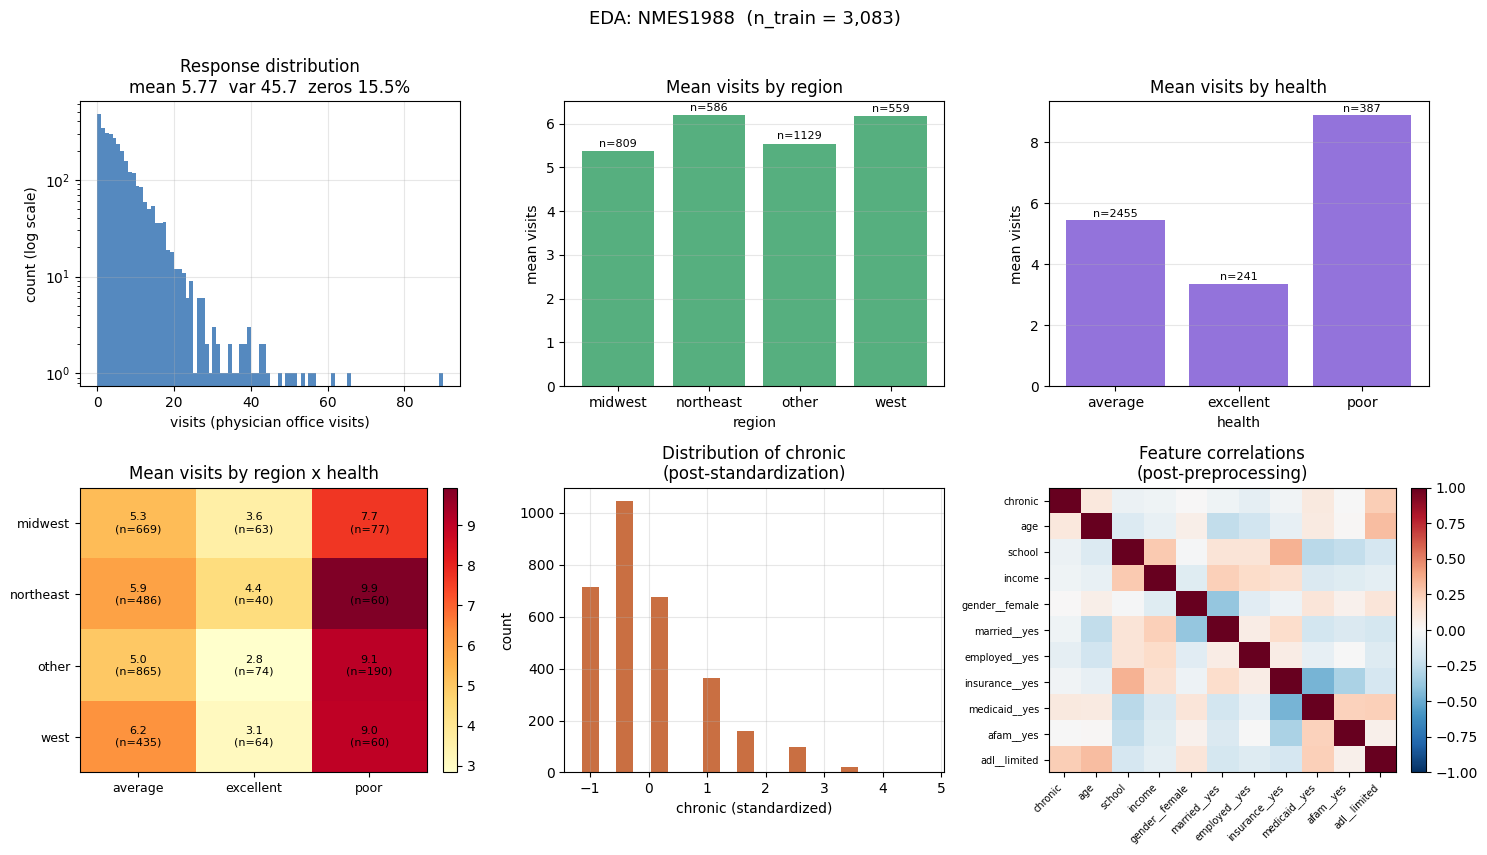



HYPERPARAMETER TUNING  (run strategy: LowMemoryRun)
  11 models total: 3 via grid search, 8 via random search

  Selection strategy: held-out validation set (no cross-validation).
    Each candidate is fit on the train set and scored on the val set
    in a single pass.  After the search, the winner is refit on
    train+val combined for honest test-set evaluation.  Implementation
    uses sklearn's GridSearchCV and RandomizedSearchCV with
    PredefinedSplit, but no k-fold CV is performed.

  Search type is selected per-model in DEFAULT_TUNING_SPECS based on
    the structure of the hyperparameter space: grid for single-knob
    discrete spaces, random when at least one dimension is continuous
    or the cross-product is large.


Tuning PLN-GLM  strategy=GRID    trials=3    hyperparameters=[lr]
  -> GridSearchCV done. best CV val ELPD/obs = -2.8635   best_params = {'lr': 0.02}
     released val_model + test_model + searcher; cleared gc + jax cache.

Tuning PLN-BNN  strategy=RANDOM  

,final_neg_elbo,val_elpd_per,val_rmse,val_mae,test_elpd_per,test_rmse,test_mae
model,,,,,,,
PLN-GLM,9980.2,-2.8635,6.9800,4.2674,-2.7800,6.9518,4.3877
PLN-BNN,12440.9,-2.8524,6.8821,4.1867,-2.7798,6.7407,4.1671
GP-PLN,10194.3,-2.8529,6.8175,4.1591,-2.7737,6.7441,4.1563
NegBin-GLM,9853.7,-2.8456,6.8764,4.1752,-2.7748,6.8498,4.2736
NegBin-BNN,10001.1,-2.8453,6.8443,4.2814,-2.7676,6.7339,4.2664
GP-NegBin,9972.7,-2.8393,6.8050,4.2515,-2.7677,6.7656,4.3227
ZI-NegBin,9807.5,-2.8316,6.8535,4.1616,-2.7632,6.8057,4.2474
ZI-NegBin-BNN,9908.4,-2.8285,6.8286,4.3099,-2.7611,6.7425,4.3310
GP-ZI-NegBin,9918.0,-2.8275,6.8242,4.1616,-2.7544,6.7347,4.1708


,final_neg_elbo,val_elpd_per,val_rmse,val_mae,test_elpd_per,test_rmse,test_mae
model,,,,,,,
GP-ZI-NegBin,9918.0,-2.8275,6.8242,4.1616,-2.7544,6.7347,4.1708
Crossed-NegBin,9871.0,-2.8508,6.9119,4.2040,-2.7564,6.7822,4.2845
ZI-NegBin-BNN,9908.4,-2.8285,6.8286,4.3099,-2.7611,6.7425,4.3310
ZI-NegBin,9807.5,-2.8316,6.8535,4.1616,-2.7632,6.8057,4.2474
NegBin-BNN,10001.1,-2.8453,6.8443,4.2814,-2.7676,6.7339,4.2664
GP-NegBin,9972.7,-2.8393,6.8050,4.2515,-2.7677,6.7656,4.3227
Hier-NegBin,9870.8,-2.8469,6.8831,4.2040,-2.7716,6.8287,4.2621
GP-PLN,10194.3,-2.8529,6.8175,4.1591,-2.7737,6.7441,4.1563
NegBin-GLM,9853.7,-2.8456,6.8764,4.1752,-2.7748,6.8498,4.2736


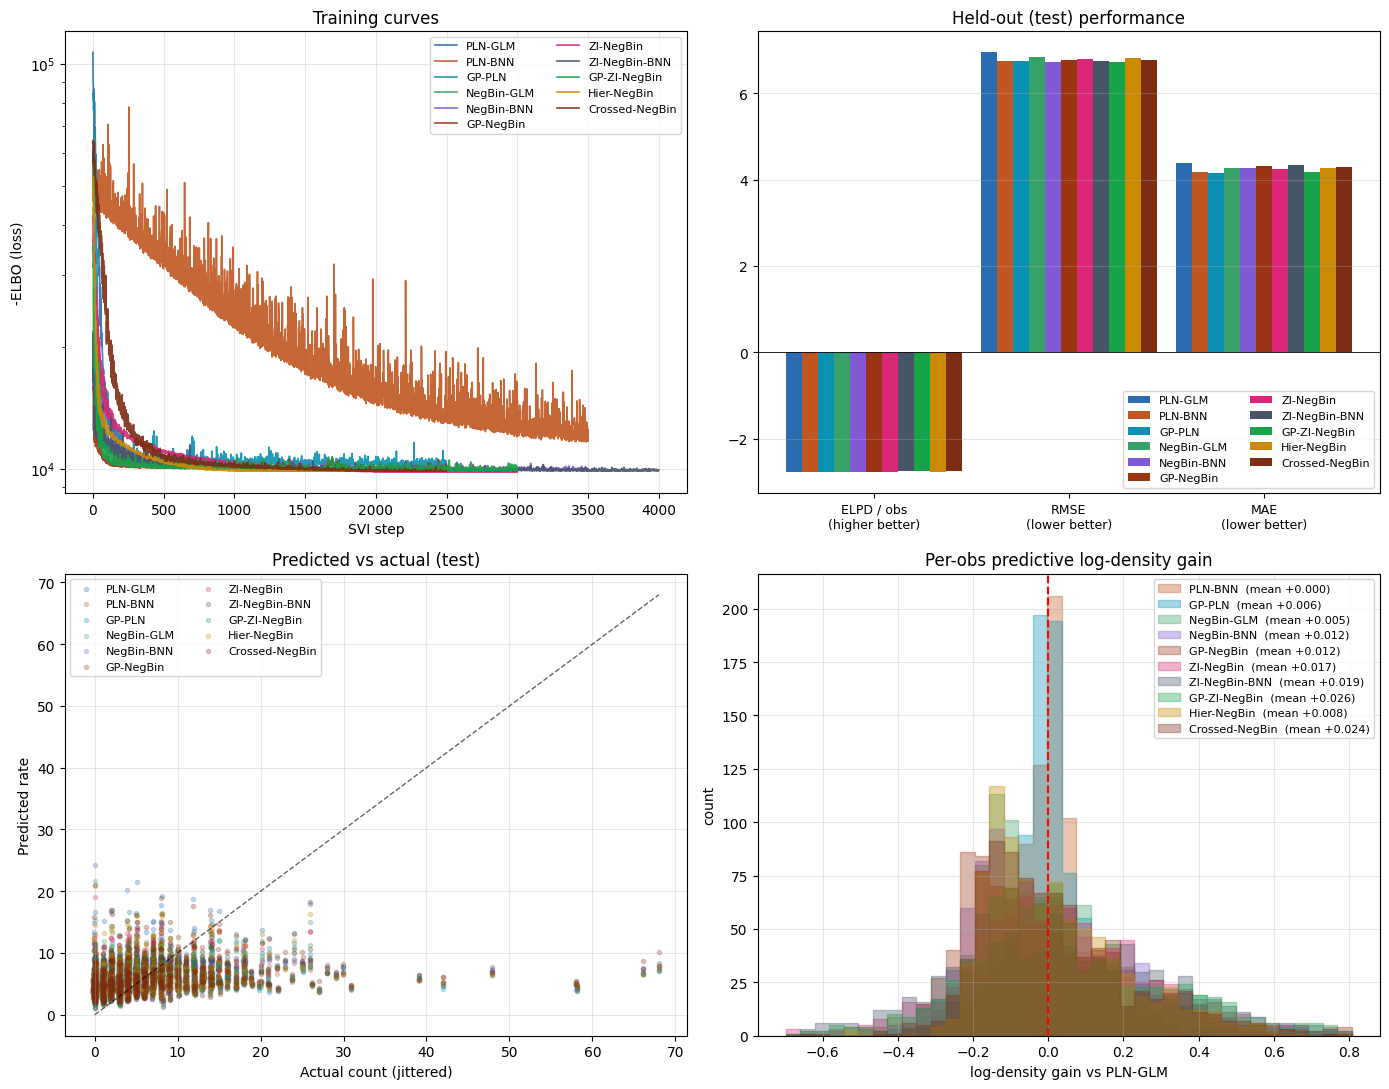

In [20]:
def main(
    outpath: Optional[str] = None,
    show: bool = True,
    tuning_specs: Optional[dict[str, TuningSpec]] = None,
    strategy: Optional[RunStrategy] = None,
) -> None:
    """Run the full pipeline: load -> EDA -> tune -> evaluate -> report.

    Pure orchestration.  All branching on memory profile and whether
    to tune is delegated to a ``RunStrategy``.  ``main`` itself just
    wires the stages together.

    Pipeline:
        1. ``load_nmes1988_data``   -> ``ThreeWaySplit``
        2. ``print_data_summary``   -> textual dataset summary
        3. ``EDAPlotter``           -> 2x3 EDA figure
        4. ``build_model_zoo``      -> list[BayesianCountRegressor] (unfitted)
        5. ``strategy.run(...)``    -> populated ``ComparisonReport``
        6. ``report.report()``      / ``report_ranked()`` / ``plot(...)``

    The strategy choice controls:
        - Whether tuning happens (``UNTUNED`` skips it; others tune).
        - Memory profile during tuning (``LOW_MEMORY`` releases fitted
          state per model; ``STANDARD`` retains all fitted models).
        - What banners and summaries get printed (each strategy speaks
          honestly about what it did).

    Args:
        outpath: If given, the comparison figure is also saved here.
        show: Whether to display figures interactively.
        tuning_specs: Per-model search specs.  Defaults to
            ``DEFAULT_TUNING_SPECS``.  Ignored by ``UNTUNED``.
        strategy: Run-strategy object controlling orchestration.
            Defaults to ``STANDARD``.  Pre-built choices:
                - ``STANDARD``    : tune all, then evaluate.  Allows
                                    post-hoc ``best_model()`` access.
                - ``LOW_MEMORY``  : interleave tune + evaluate + release
                                    per model.  Caps peak RAM.
                - ``UNTUNED``     : skip tuning; fit with defaults.
            Subclass ``RunStrategy`` to add custom orchestrations.
    """
    if strategy is None:
        strategy = STANDARD

    # Stage 1: data
    split = load_nmes1988_data(test_size=0.20, val_size=0.10)
    print_data_summary(split)

    # Stage 2: EDA
    EDAPlotter(split).plot(show=show)

    # Stage 3: build zoo
    models = build_model_zoo(
        n_groups_a=split.meta['n_groups_a'],
        n_groups_b=split.meta['n_groups_b'],
    )

    # Stages 4 + 5: delegated to the strategy.  The strategy owns its
    # own banner and summary.
    strategy.print_pre_run_banner(models, tuning_specs)
    comparison = strategy.run(
        models,
        split,
        tuning_specs=tuning_specs,
        verbose=0,
    )
    strategy.print_post_run_summary(comparison)

    # Stage 6: report + plot (uniform across all strategies)
    comparison.report()           # canonical zoo order
    comparison.report_ranked()    # sorted by test_elpd_per (best first)
    comparison.plot(outpath=outpath, show=show)


if __name__ == "__main__":
    main(strategy=LOW_MEMORY)